# Spotify Popularity Analysis

**Domanda di ricerca:** le caratteristiche audio di un brano (danceability, energy, tempo, ...) e il suo genere musicale permettono di prevedere quanto sarà popolare su Spotify?

**Dataset:** *Spotify Tracks Dataset* (Kaggle, autore maharshipandya): 114.000 tracce (1.000 per ciascuno dei 114 generi) con feature audio, genere musicale e `popularity` (indice 0-100 assegnato da Spotify).

**Struttura del notebook**
1. Setup e caricamento dei dati
2. Pulizia di base
3. Analisi della variabile target (inclusa la deduplica)
4. Analisi esplorativa delle variabili numeriche e pulizia degli outlier
5. Classi di popolarità
6. Analisi delle variabili categoriche
7. Modelli: Regressione Logistica e LightGBM (confronto, calibrazione delle probabilità, contributo di genere e feature audio, importanza delle feature, SHAP, controllo di robustezza)
8. Conclusioni

**Per eseguirlo:** scarica il CSV da Kaggle in `data/dataset.csv`, installa le dipendenze (`pip install -r requirements.txt`) ed esegui il notebook dall'inizio alla fine. I grafici vengono salvati automaticamente nella cartella `figures/`.

## 1. Setup e caricamento dei dati

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import shap
from sklearn.calibration import calibration_curve

In [ ]:
# --- Percorsi e parametri generali ---
DATA_PATH = Path("data\dataset.csv")
RANDOM_STATE = 42
TARGET = "popularity"

# --- Definizione delle feature ---
NUMERIC_FEATURES = [
    "duration_ms", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]
CATEGORICAL_FEATURES = ["track_genre", "explicit", "key_name", "mode", "time_signature"]
SONG_KEY = ["track_name", "artists"]  # identifica "lo stesso brano"
CLASS_LABELS = ["bassa", "medio-bassa", "medio-alta", "alta"]

# --- Parametri di pulizia ---
AUDIO_TOLERANCES = {  # differenze massime ammesse tra due osservazioni per considerarle "audio uguale"
    "duration_ms": 6000, "loudness": 1.0, "tempo": 1.0,
    "danceability": 0.01, "energy": 0.01, "speechiness": 0.01, "acousticness": 0.01,
    "instrumentalness": 0.01, "liveness": 0.01, "valence": 0.01,
}
DURATION_QUANTILES = [0.005, 0.995]
TEMPO_MIN = 50  # BPM

# --- Altri parametri ---
LGBM_PARAMS = {
    "n_estimators": 500,
    "importance_type": "gain",  # importanza delle feature misurata come guadagno totale (sezione 7.7)
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}
MIN_GENRE_TRACKS = 200  # generi con meno tracce sono esclusi dal confronto tra generi

# --- Registro dei passaggi di pulizia (riepilogo a fine sezione 4) ---
cleaning_log = []


def log_step(data, label):
    """Registra il numero di righe dopo un passaggio di pulizia."""
    cleaning_log.append({"step": label, "rows": len(data), "zeri": int((data[TARGET] == 0).sum())})
    print(f"{label}: {len(data):,} righe")


# --- Stile dei grafici ---
PRIMARY, ALERT, NEUTRAL = "#1DB954", "#E4572E", "#3D5A80"  # verde Spotify, rosso (evidenza), blu
CLASS_COLORS = dict(zip(CLASS_LABELS, sns.color_palette("crest", 4)))  # scala ordinata: bassa -> alta

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def show(fig, name):
    """Salva il grafico in figures/ (riutilizzabile nel README) e lo mostra."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [6]:
# `track_id` (id Spotify) identifica la registrazione e resta nel dataset per tutta l'analisi (non è una feature del modello).
# Si ripete quando la stessa registrazione compare in più generi (89.741 valori distinti su 114.000 righe), quindi non può
# identificare la singola riga: per rimuovere una copia e tenere le altre serve anche il numero di riga del CSV
# ("Unnamed: 0" -> `row_id`), usato solo come indice tecnico di riga, mai come identificatore del brano.
# Lo split train/test (sezione 7.1) tiene insieme le righe dello stesso brano tramite `group_id`.
df = pd.read_csv(DATA_PATH).rename(columns={"Unnamed: 0": "row_id"})
log_step(df, "Dataset originale")
df.head()

Dataset originale: 114,000 righe


,row_id,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
df.info()
print(f"\nGeneri musicali distinti: {df['track_genre'].nunique()} | tracce per genere: {df['track_genre'].value_counts().unique().tolist()}")

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   row_id            114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

## 2. Pulizia di base

In [8]:
# Valori mancanti
missing = df.isna().sum()
print(f"Righe con almeno un valore mancante: {df.isna().any(axis=1).sum()}")
print(missing[missing > 0].to_string())

df = df.dropna()
log_step(df, "Dopo rimozione valori mancanti")

Righe con almeno un valore mancante: 1
artists       1
album_name    1
track_name    1
Dopo rimozione valori mancanti: 113,999 righe


In [9]:
# --- Duplicati esatti ---
# Stessa traccia (titolo + artista), stessa popularity, stesso audio e stesse variabili categoriche.
# track_genre NON è nel confronto: serve solo a stabilire quale copia tenere.
CATEGORICAL_MATCH = ["key", "mode", "time_signature", "explicit"]
exact_columns = SONG_KEY + [TARGET] + NUMERIC_FEATURES + CATEGORICAL_MATCH

# Tra copie identiche si tiene quella con `priority` più bassa. Ogni genere ha esattamente 1.000 tracce, quindi nessun genere
# è "meno rappresentato": la priorità è un ordine casuale riproducibile, assegnato UNA volta prima di qualsiasi rimozione.
df["priority"] = np.random.default_rng(RANDOM_STATE).permutation(len(df))
df = df.sort_values("priority")
n_songs_initial = len(df.drop_duplicates(SONG_KEY))   # brani distinti (titolo + artista), per il controllo finale

rows_before = len(df)
in_duplicate_groups = df.duplicated(subset=exact_columns, keep=False)   # tutte le copie
to_remove = df.duplicated(subset=exact_columns, keep="first")           # tutte tranne la prima

print(f"Righe iniziali: {rows_before:,}")
print(f"Osservazioni appartenenti a gruppi di duplicati esatti: {in_duplicate_groups.sum():,}")
print(f"  di cui mantenute (una per gruppo): {(in_duplicate_groups & ~to_remove).sum():,}")
print(f"  di cui da rimuovere: {to_remove.sum():,}")
genres_per_group = df[in_duplicate_groups].groupby(exact_columns)["track_genre"].nunique()
print(f"Gruppi di duplicati con copie in generi diversi: {(genres_per_group > 1).sum():,} su {len(genres_per_group):,}")

df = df[~to_remove].sort_values("row_id")
log_step(df, "Dopo rimozione duplicati esatti")
print(f"Righe rimosse: {rows_before - len(df):,} | Righe rimanenti: {len(df):,}")

Righe iniziali: 113,999
Osservazioni appartenenti a gruppi di duplicati esatti: 42,663
  di cui mantenute (una per gruppo): 15,399
  di cui da rimuovere: 27,264
Gruppi di duplicati con copie in generi diversi: 14,285 su 15,399
Dopo rimozione duplicati esatti: 86,735 righe
Righe rimosse: 27,264 | Righe rimanenti: 86,735


## 3. Analisi della variabile target

La variabile target è `popularity`, un indice numerico da 0 a 100. Osserviamo la sua distribuzione e, in particolare, la presenza di molti valori pari a 0.

In [10]:
df[TARGET].describe()

count    86735.000000
mean        34.629711
std         19.854697
min          0.000000
25%         21.000000
50%         35.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64

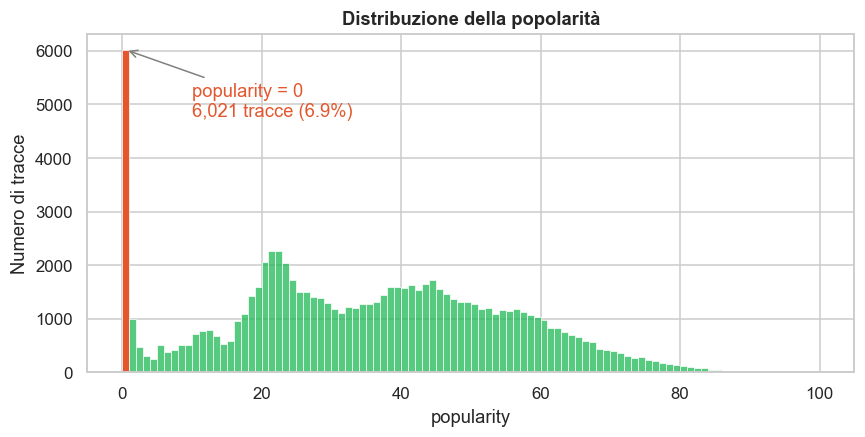

In [11]:
n_zero = (df[TARGET] == 0).sum()
zero_share = n_zero / len(df)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df[TARGET], bins=100, color=PRIMARY, ax=ax)
zero_bar = ax.patches[0]  # primo intervallo: solo popularity = 0
zero_bar.set_facecolor(ALERT)
ax.annotate(
    f"popularity = 0\n{n_zero:,} tracce ({zero_share:.1%})",
    xy=(0.5, zero_bar.get_height()), xytext=(10, zero_bar.get_height() * 0.9),
    arrowprops={"arrowstyle": "->", "color": "gray"}, color=ALERT, va="top",
)
ax.set(title="Distribuzione della popolarità", xlabel="popularity", ylabel="Numero di tracce")
show(fig, "01_distribuzione_popularity")

### 3.1 Le tracce con `popularity = 0`

La quota di zeri varia molto da un genere all'altro:

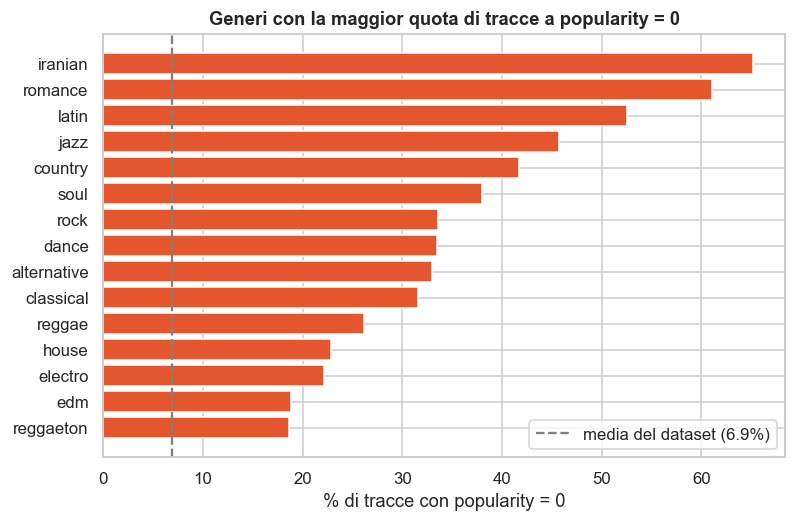

In [12]:
zero_share_by_genre = (df[TARGET] == 0).groupby(df["track_genre"]).mean().sort_values(ascending=False)

top = zero_share_by_genre.head(15).iloc[::-1] * 100
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=ALERT)
ax.axvline(zero_share * 100, color="gray", ls="--", label=f"media del dataset ({zero_share:.1%})")
ax.set(title="Generi con la maggior quota di tracce a popularity = 0", xlabel="% di tracce con popularity = 0", ylabel="")
ax.legend(loc="lower right")
show(fig, "02_zeri_per_genere")

### 3.2 Duplicati e quasi duplicati

Dopo i duplicati esatti (sezione 2) si cercano i quasi duplicati con la sequenza:

`track_name + artists` (candidati) → confronto audio → confronto variabili categoriche → osservazioni da eliminare

- **Audio uguale**: ogni feature audio differisce al massimo della tolleranza definita in `AUDIO_TOLERANCES`.
- **Categoriche uguali**: `key`, `mode`, `time_signature`, `explicit` (l'audio viene verificato per primo).
- Titolo e artista individuano solo i candidati: non bastano per dire che due osservazioni sono la stessa traccia.
- Tra osservazioni duplicate si tiene quella con `priority` più bassa (ordine casuale riproducibile, vedi sezione 2). La stessa registrazione può comparire in più generi: quale genere resti associato alla copia tenuta è quindi una scelta arbitraria, non un'informazione del dataset.

Fasi: (A) tracce a `popularity = 0` con una copia positiva; (B) duplicati tra tracce a `popularity = 0`; (C) duplicati tra tracce positive **con la stessa popularity**. Tracce positive con popularity diversa non si confrontano e restano nel dataset.

In [13]:
# Tolleranze audio: una per ogni feature
TOLERANCES = pd.Series(AUDIO_TOLERANCES)[NUMERIC_FEATURES]   # stesso ordine delle colonne


def same_audio(track, others, tolerances=TOLERANCES):
    """Per ogni riga di `others`: True se l'audio coincide con quello di `track` entro le tolleranze."""
    differences = (others[NUMERIC_FEATURES] - track[NUMERIC_FEATURES].astype(float)).abs()
    return (differences <= tolerances).all(axis=1)


def same_categories(track, others):
    """Per ogni riga di `others`: True se le variabili categoriche coincidono con quelle di `track`."""
    return (others[CATEGORICAL_MATCH] == track[CATEGORICAL_MATCH]).all(axis=1)


def zeros_with_positive_copy(zeros, positives, tolerances=TOLERANCES):
    """Tracce a popularity = 0 che hanno una copia positiva (stesso titolo/artista, audio e categoriche uguali)."""
    positives_by_song = dict(tuple(positives.groupby(SONG_KEY)))
    ids_to_remove = []
    n_candidates = 0

    for _, zero in zeros.iterrows():
        same_song = positives_by_song.get((zero["track_name"], zero["artists"]))
        if same_song is None:
            continue                                   # nessun candidato
        n_candidates += 1
        audio_ok = same_audio(zero, same_song, tolerances)
        if audio_ok.any() and same_categories(zero, same_song[audio_ok]).any():
            ids_to_remove.append(zero["row_id"])       # audio E categoriche confermati
    return ids_to_remove, n_candidates


def duplicates_same_popularity(data, tolerances=TOLERANCES):
    """Duplicati tra tracce con stesso titolo, artista e stessa popularity.
    In ogni gruppo si tiene la prima traccia (priorità più bassa); le altre si eliminano
    se il loro audio E le loro categoriche coincidono con quelli di una traccia già mantenuta."""
    candidates = data[data.duplicated(SONG_KEY + [TARGET], keep=False)]
    candidates = candidates.sort_values("priority")
    ids_to_remove = []

    for _, group in candidates.groupby(SONG_KEY + [TARGET]):
        kept = group.iloc[[0]]
        for position in range(1, len(group)):
            track = group.iloc[position]
            audio_ok = same_audio(track, kept, tolerances)
            if audio_ok.any() and same_categories(track, kept[audio_ok]).any():
                ids_to_remove.append(track["row_id"])   # duplicato: non si mantiene
                continue
            kept = pd.concat([kept, group.iloc[[position]]])   # diversa dalle altre: si mantiene
    return ids_to_remove, len(candidates)

**Nota metodologica.** Le fasi A–C non sono una deduplica neutra: la fase A elimina le tracce a `popularity = 0` quando esiste una copia positiva, cioè seleziona le righe in base al target. È una scelta di pulizia dichiarata (lo zero è spesso un'assenza di dato, non una popolarità reale), ma va riportata come tale. Prima di applicarla misuriamo quanto le tolleranze audio contano davvero: la cella seguente è solo diagnostica e non modifica `df`.

In [14]:
# --- Sensibilità alle tolleranze audio (diagnostica: non modifica df) ---
def dedup_summary(data, scale):
    """Numero di righe rimosse dalle fasi A, B, C con tolleranze moltiplicate per `scale` (0 = audio identico)."""
    tolerances = TOLERANCES * scale
    ids_a, _ = zeros_with_positive_copy(data[data[TARGET] == 0], data[data[TARGET] > 0], tolerances)
    after_a = data[~data["row_id"].isin(ids_a)]
    ids_b, _ = duplicates_same_popularity(after_a[after_a[TARGET] == 0], tolerances)
    after_b = after_a[~after_a["row_id"].isin(ids_b)]
    ids_c, _ = duplicates_same_popularity(after_b[after_b[TARGET] > 0], tolerances)
    return {"scala tolleranze": scale, "fase A": len(ids_a), "fase B": len(ids_b), "fase C": len(ids_c),
            "totale rimosse": len(ids_a) + len(ids_b) + len(ids_c)}


pd.DataFrame([dedup_summary(df, scale) for scale in [0, 0.5, 1]]).set_index("scala tolleranze")

,fase A,fase B,fase C,totale rimosse
scala tolleranze,,,,
0.0,805,0,0,805
0.5,918,4,3,925
1.0,938,5,6,949


#### Fase A: tracce con `popularity = 0` che hanno una copia positiva

Se la stessa traccia esiste con `popularity > 0`, si elimina la versione a 0 e si mantiene quella positiva (la differenza riguarda il target).

In [15]:
rows_before = len(df)
zeros_to_remove, n_candidates = zeros_with_positive_copy(df[df[TARGET] == 0], df[df[TARGET] > 0])

print(f"Righe iniziali: {rows_before:,}")
print(f"Tracce a popularity = 0 candidate (stesso titolo e artista di una traccia positiva): {n_candidates:,}")
print(f"  con audio e categoriche uguali (duplicate): {len(zeros_to_remove):,}")
print(f"Osservazioni da rimuovere: {len(zeros_to_remove):,}")

df = df[~df["row_id"].isin(zeros_to_remove)]
log_step(df, "Dopo rimozione zeri con copia positiva")
print(f"Righe rimosse: {rows_before - len(df):,} | Righe rimanenti: {len(df):,}")

Righe iniziali: 86,735
Tracce a popularity = 0 candidate (stesso titolo e artista di una traccia positiva): 1,208
  con audio e categoriche uguali (duplicate): 938
Osservazioni da rimuovere: 938
Dopo rimozione zeri con copia positiva: 85,797 righe
Righe rimosse: 938 | Righe rimanenti: 85,797


#### Fase B: duplicati tra tracce con `popularity = 0`

In [16]:
rows_before = len(df)
zero_duplicates, n_candidates = duplicates_same_popularity(df[df[TARGET] == 0])

print(f"Righe iniziali: {rows_before:,}")
print(f"Tracce candidate (stesso titolo e artista): {n_candidates:,}")
print(f"  con audio e categoriche uguali (duplicate): {len(zero_duplicates):,}")
print(f"Osservazioni da rimuovere: {len(zero_duplicates):,}")

df = df[~df["row_id"].isin(zero_duplicates)]
log_step(df, "Dopo deduplica tra tracce con popularity = 0")
print(f"Righe rimosse: {rows_before - len(df):,} | Righe rimanenti: {len(df):,}")

Righe iniziali: 85,797
Tracce candidate (stesso titolo e artista): 116
  con audio e categoriche uguali (duplicate): 5
Osservazioni da rimuovere: 5
Dopo deduplica tra tracce con popularity = 0: 85,792 righe
Righe rimosse: 5 | Righe rimanenti: 85,792


#### Fase C: duplicati tra tracce con `popularity > 0` e stessa popularity

In [17]:
rows_before = len(df)
positive_duplicates, n_candidates = duplicates_same_popularity(df[df[TARGET] > 0])

print(f"Righe iniziali: {rows_before:,}")
print(f"Tracce candidate (stesso titolo, artista e popularity): {n_candidates:,}")
print(f"  con audio e categoriche uguali (duplicate): {len(positive_duplicates):,}")
print(f"Osservazioni da rimuovere: {len(positive_duplicates):,}")

df = df[~df["row_id"].isin(positive_duplicates)]
log_step(df, "Dopo deduplica tra tracce con popularity > 0")
print(f"Righe rimosse: {rows_before - len(df):,} | Righe rimanenti: {len(df):,}")

Righe iniziali: 85,792
Tracce candidate (stesso titolo, artista e popularity): 211
  con audio e categoriche uguali (duplicate): 6
Osservazioni da rimuovere: 6
Dopo deduplica tra tracce con popularity > 0: 85,786 righe
Righe rimosse: 6 | Righe rimanenti: 85,786


#### Controllo finale

Ripetiamo le ricerche sul dataset ripulito: tutti i valori devono essere 0.

In [18]:
print(f"Duplicati esatti residui: {df.duplicated(subset=exact_columns).sum()}")
print(f"Zeri con copia positiva residui: {len(zeros_with_positive_copy(df[df[TARGET] == 0], df[df[TARGET] > 0])[0])}")
print(f"Duplicati residui tra zeri: {len(duplicates_same_popularity(df[df[TARGET] == 0])[0])}")
print(f"Duplicati residui tra positive (stessa popularity): {len(duplicates_same_popularity(df[df[TARGET] > 0])[0])}")

# Nessun brano deve essere sparito del tutto
n_songs = len(df.drop_duplicates(SONG_KEY))
print(f"Brani distinti (titolo + artista): {n_songs:,} (prima della deduplica: {n_songs_initial:,}) | Righe finali: {len(df):,}")
assert n_songs == n_songs_initial, "la deduplica ha eliminato del tutto qualche brano"

# track_id ancora ripetuti: stessa registrazione presente in generi diversi con popularity leggermente diversa
# (la fase C richiede popularity uguale). Restano nel dataset, ma lo split della sezione 7.1 le tiene insieme.
repeated_ids = df[df.duplicated("track_id", keep=False)]
print(f"track_id ancora ripetuti: {repeated_ids['track_id'].nunique():,} ({len(repeated_ids):,} righe)")

df = df.drop(columns="priority")   # colonna di servizio, non serve più

Duplicati esatti residui: 0
Zeri con copia positiva residui: 0
Duplicati residui tra zeri: 0
Duplicati residui tra positive (stessa popularity): 0
Brani distinti (titolo + artista): 81,343 (prima della deduplica: 81,343) | Righe finali: 85,786
track_id ancora ripetuti: 594 (1,188 righe)


Le tracce rimaste con lo stesso titolo e artista ma audio o categoriche diverse (per esempio versioni live o remix) non sono duplicati e restano nel dataset. Anche le tracce a `popularity = 0` rimaste vengono mantenute: la sezione 4.3 mostra che le correlazioni con il target cambiano di poco se le si esclude.

In [19]:
# Da qui in poi l'analisi lavora su df_clean
df_clean = df.copy()
print(f"Osservazioni dopo la deduplica: {len(df_clean):,}")

Osservazioni dopo la deduplica: 85,786


## 4. Analisi esplorativa delle variabili numeriche

### 4.1 Distribuzioni

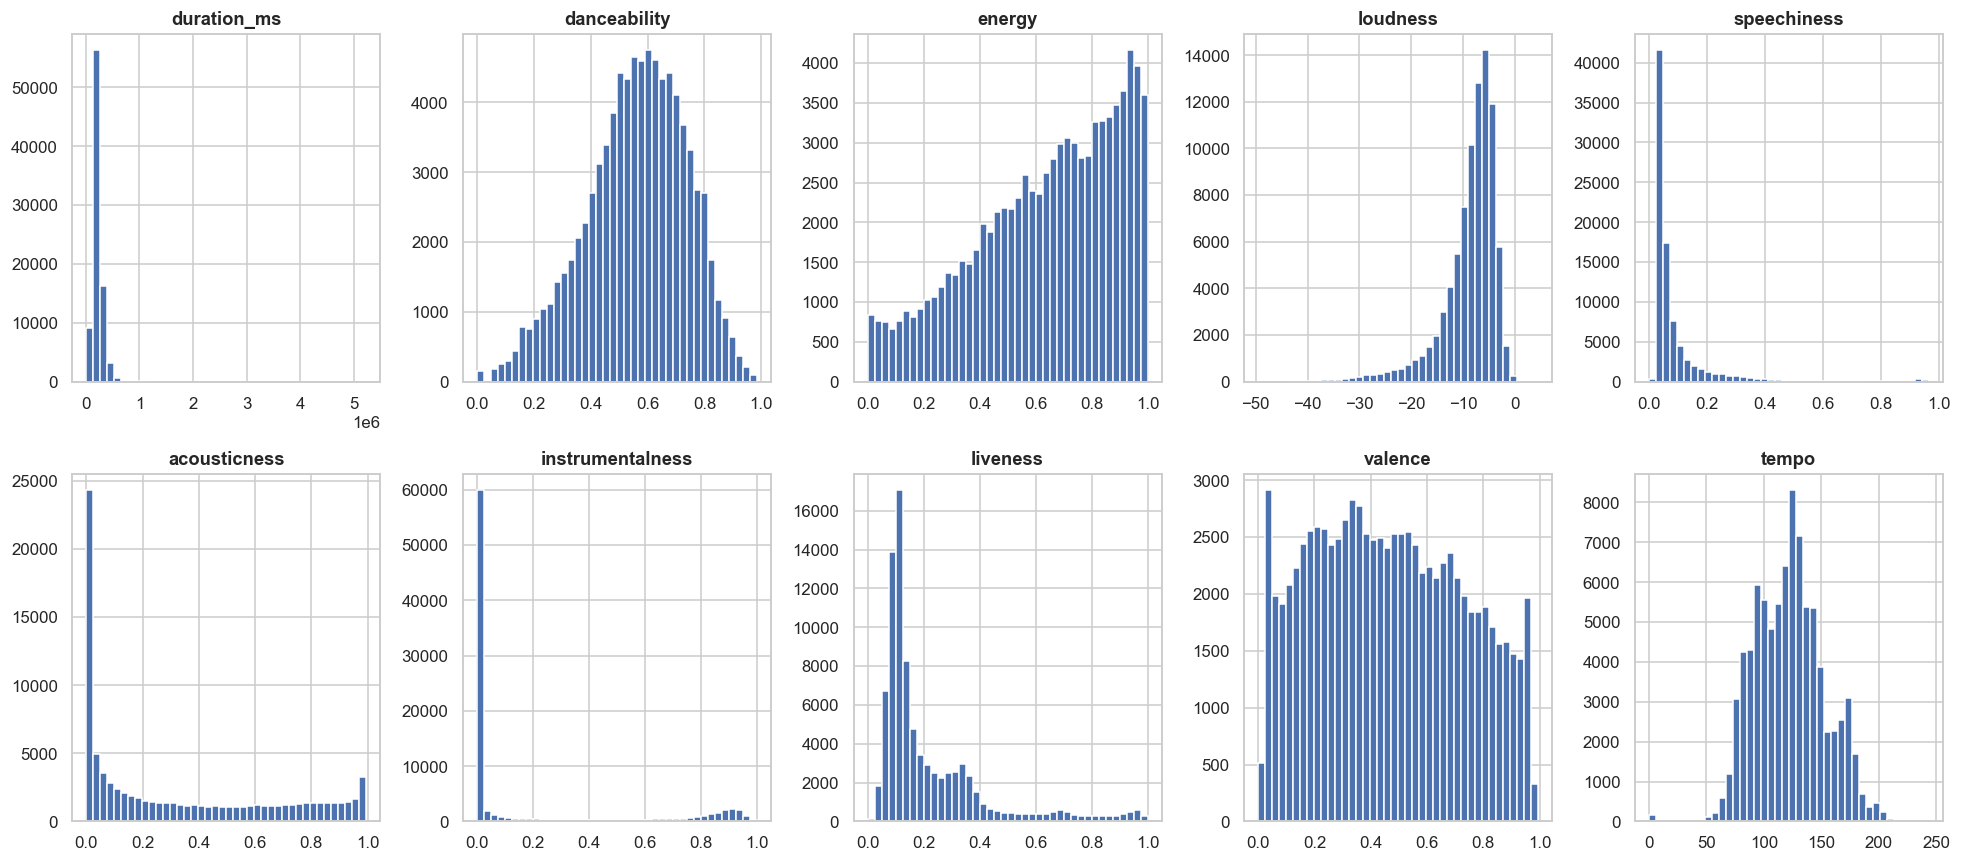

In [20]:
df_clean[NUMERIC_FEATURES].hist(bins=40, figsize=(18, 8), layout=(2, 5))
plt.tight_layout()
show(plt.gcf(), "05_distribuzioni_feature")

### 4.2 Pulizia degli outlier

#### Durata (`duration_ms`)

La durata ha una forte asimmetria positiva.

In [21]:
df_clean["duration_ms"].describe()

count    8.578600e+04
mean     2.308335e+05
std      1.147879e+05
min      8.586000e+03
25%      1.739012e+05
50%      2.149860e+05
75%      2.664930e+05
max      5.237295e+06
Name: duration_ms, dtype: float64

In [22]:
# Durata media e numerosità per fascia di durata (in minuti)
duration_min = df_clean["duration_ms"] / 60_000
df_clean.groupby(pd.cut(duration_min, bins=[0, 2, 4, 6, 10, 20, 60, 80, 90]), observed=True)[TARGET].agg(["mean", "count"])

,mean,count
duration_ms,,
"(0, 2]",28.855876,5412
"(2, 4]",36.574167,49463
"(4, 6]",35.043263,24386
"(6, 10]",28.503598,5975
"(10, 20]",23.802935,477
"(20, 60]",25.758621,58
"(60, 80]",21.571429,14
"(80, 90]",35.000000,1


In [23]:
# Le 10 tracce più lunghe e le 10 più corte
extremes = pd.concat([df_clean.nlargest(10, "duration_ms"), df_clean.nsmallest(10, "duration_ms")])
extremes[["track_name", "artists", "track_genre", "duration_ms"]]

,track_name,artists,track_genre,duration_ms
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,minimal-techno,5237295
10984,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,breakbeat,4789026
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,detroit-techno,4730302
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,minimal-techno,4563897
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,chicago-house,4447520
13245,Live In Tokyo - Continuous Mix,Mark Farina,chicago-house,4339826
13195,Greenhouse Construction,Mark Farina,chicago-house,4334721
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman;Dan Stezo,drum-and-bass,4246206
101390,Ocean Waves Sounds,Ocean Sounds,sleep,4120258
45063,Internal Flight (Remastered),Estas Tonne,guitar,3876276


Gli estremi non sono errori, ma contenuti diversi da una "canzone tipica": frammenti e jingle di pochi secondi da un lato, DJ mix e audio ambientali di oltre un'ora dall'altro. Non sono confrontabili con un brano di 3 minuti (le feature audio medie di un mix di un'ora hanno un significato diverso), quindi sono fuori dallo scopo dell'analisi.

Con distribuzioni molto asimmetriche il criterio IQR è poco affidabile sul lato della coda lunga: si usano quindi i **percentili empirici**, che non assumono alcuna forma della distribuzione.

Soglie IQR:        [35 s, 6.8 min]
Soglie percentili: [50 s, 10.7 min]


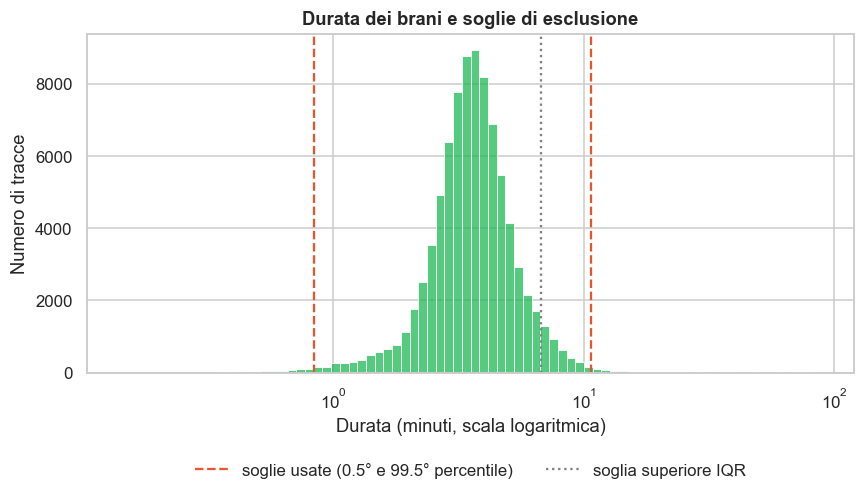

In [24]:
q_low, q_high = df_clean["duration_ms"].quantile(DURATION_QUANTILES)
q1, q3 = df_clean["duration_ms"].quantile([0.25, 0.75])
iqr_low, iqr_high = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)

print(f"Soglie IQR:        [{iqr_low / 1000:.0f} s, {iqr_high / 60_000:.1f} min]")
print(f"Soglie percentili: [{q_low / 1000:.0f} s, {q_high / 60_000:.1f} min]")

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df_clean["duration_ms"] / 60_000, bins=80, log_scale=True, color=PRIMARY, ax=ax)
ax.axvline(q_low / 60_000, color=ALERT, ls="--", label="soglie usate (0.5° e 99.5° percentile)")
ax.axvline(q_high / 60_000, color=ALERT, ls="--")
ax.axvline(iqr_high / 60_000, color="gray", ls=":", label="soglia superiore IQR")
ax.set(title="Durata dei brani e soglie di esclusione", xlabel="Durata (minuti, scala logaritmica)", ylabel="Numero di tracce")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)
show(fig, "03_durata_soglie")

In [25]:
df_clean = df_clean[df_clean["duration_ms"].between(q_low, q_high)].reset_index(drop=True)
log_step(df_clean, "Dopo filtro sulla durata")

df_clean["duration_ms"].describe()

Dopo filtro sulla durata: 84,928 righe


count     84928.000000
mean     227712.560027
std       83959.304179
min       50440.000000
25%      174315.000000
50%      214986.000000
75%      265822.250000
max      640724.000000
Name: duration_ms, dtype: float64

Sono state rimosse le tracce sotto lo 0.5° e sopra il 99.5° percentile, mantenendo il 99% delle osservazioni e concentrando l'analisi sulla durata tipica dei brani.

#### Tempo (`tempo`)

count    84928.000000
mean       122.260685
std         30.086191
min          0.000000
25%         99.667750
50%        122.053000
75%        140.204250
max        243.372000
Name: tempo, dtype: float64

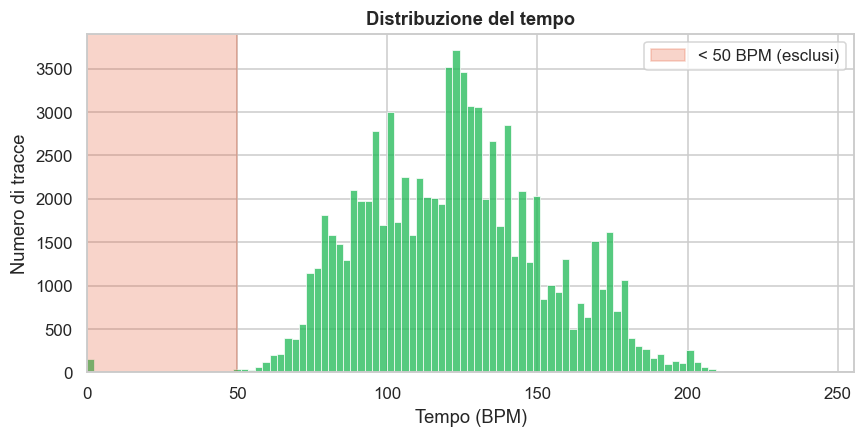

Righe con tempo sotto soglia:
  tempo < 10: 149
  tempo < 20: 149
  tempo < 30: 149
  tempo < 40: 166
  tempo < 50: 219
  tempo < 60: 453


In [26]:
display(df_clean["tempo"].describe())

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df_clean["tempo"], bins=100, color=PRIMARY, ax=ax)
ax.axvspan(0, TEMPO_MIN, color=ALERT, alpha=0.25, label=f"< {TEMPO_MIN} BPM (esclusi)")
ax.set(title="Distribuzione del tempo", xlabel="Tempo (BPM)", ylabel="Numero di tracce", xlim=(0, None))
ax.legend()
show(fig, "04_tempo_soglia")

print("Righe con tempo sotto soglia:")
for threshold in [10, 20, 30, 40, 50, 60]:
    print(f"  tempo < {threshold}: {(df_clean['tempo'] < threshold).sum():,}")

In [27]:
low_tempo = df_clean[df_clean["tempo"] < TEMPO_MIN]
print(f"Generi distinti con tempo < {TEMPO_MIN} BPM: {low_tempo['track_genre'].nunique()}")
display(low_tempo["track_genre"].value_counts().head(10))
low_tempo.nsmallest(10, "tempo")[["track_name", "artists", "track_genre", "tempo", TARGET]]

Generi distinti con tempo < 50 BPM: 31


track_genre
sleep          142
comedy          12
ambient          7
guitar           5
new-age          5
show-tunes       5
classical        4
piano            4
world-music      4
romance          3
Name: count, dtype: int64

,track_name,artists,track_genre,tempo,popularity
2609,The Departure,Max Richter;Lang Lang,ambient,0.0,64
2816,The End of Childhood (feat. Jack Liebeck),Dario Marianelli;Jack Liebeck;Benjamin Wallfisch,ambient,0.0,55
3065,Ferme Les Yeux,Sylvain Chauveau,ambient,0.0,53
34555,Campomoro,Little Symphony,guitar,0.0,22
34604,Ritornello,Little Symphony,guitar,0.0,23
34613,Amager,Little Symphony,guitar,0.0,22
34656,Ionian,Little Symphony,guitar,0.0,22
48480,"Hello, Dolly!",Louis Armstrong,jazz,0.0,62
57259,Le bourgeois gentilhomme: Chaconne des Scaramo...,Jean-Baptiste Lully;Mary Enid Haines;Sharla Na...,opera,0.0,51
57278,"Carmen (1997 - Remaster), Act I: Quels regarde...",Georges Bizet;Maria Callas;Nicolai Gedda;Orche...,opera,0.0,22


I valori sotto i 50 BPM, analizzati manualmente, sono in parte `tempo = 0` (valore non rilevato da Spotify) e in parte brani di generi senza una pulsazione ritmica convenzionale (soprattutto `sleep`, poi ambient, classical, opera). In questi casi il tempo stimato è poco rappresentativo della struttura musicale e introdurrebbe rumore: le tracce vengono escluse.

In [28]:
df_clean = df_clean[df_clean["tempo"] >= TEMPO_MIN].reset_index(drop=True)
log_step(df_clean, f"Dopo filtro tempo >= {TEMPO_MIN} BPM")

Dopo filtro tempo >= 50 BPM: 84,709 righe


#### Riepilogo della pulizia

In [29]:
cleaning_summary = pd.DataFrame(cleaning_log)
initial_rows = cleaning_summary.loc[0, "rows"]

cleaning_summary["rimosse"] = (-cleaning_summary["rows"].diff()).fillna(0).astype(int)
cleaning_summary["% del dataset originale"] = (cleaning_summary["rows"] / initial_rows * 100).round(1)
cleaning_summary["quota popularity = 0 (%)"] = (cleaning_summary["zeri"] / cleaning_summary["rows"] * 100).round(1)
display(cleaning_summary)

total_removed = initial_rows - cleaning_summary["rows"].iloc[-1]
print(f"Righe rimosse in totale: {total_removed:,} ({total_removed / initial_rows:.1%}) | "
      f"righe finali: {len(df_clean):,}")
assert cleaning_summary["rows"].iloc[-1] == len(df_clean), "il registro non coincide con df_clean"

,step,rows,zeri,rimosse,% del dataset originale,quota popularity = 0 (%)
0,Dataset originale,114000,16020,0,100.0,14.1
1,Dopo rimozione valori mancanti,113999,16019,1,100.0,14.1
2,Dopo rimozione duplicati esatti,86735,6021,27264,76.1,6.9
3,Dopo rimozione zeri con copia positiva,85797,5083,938,75.3,5.9
4,Dopo deduplica tra tracce con popularity = 0,85792,5078,5,75.3,5.9
5,Dopo deduplica tra tracce con popularity > 0,85786,5078,6,75.3,5.9
6,Dopo filtro sulla durata,84928,4993,858,74.5,5.9
7,Dopo filtro tempo >= 50 BPM,84709,4983,219,74.3,5.9


Righe rimosse in totale: 29,291 (25.7%) | righe finali: 84,709


### 4.3 Correlazioni

Si usa la correlazione di **Spearman**, adatta a distribuzioni asimmetriche e a relazioni monotone non necessariamente lineari.

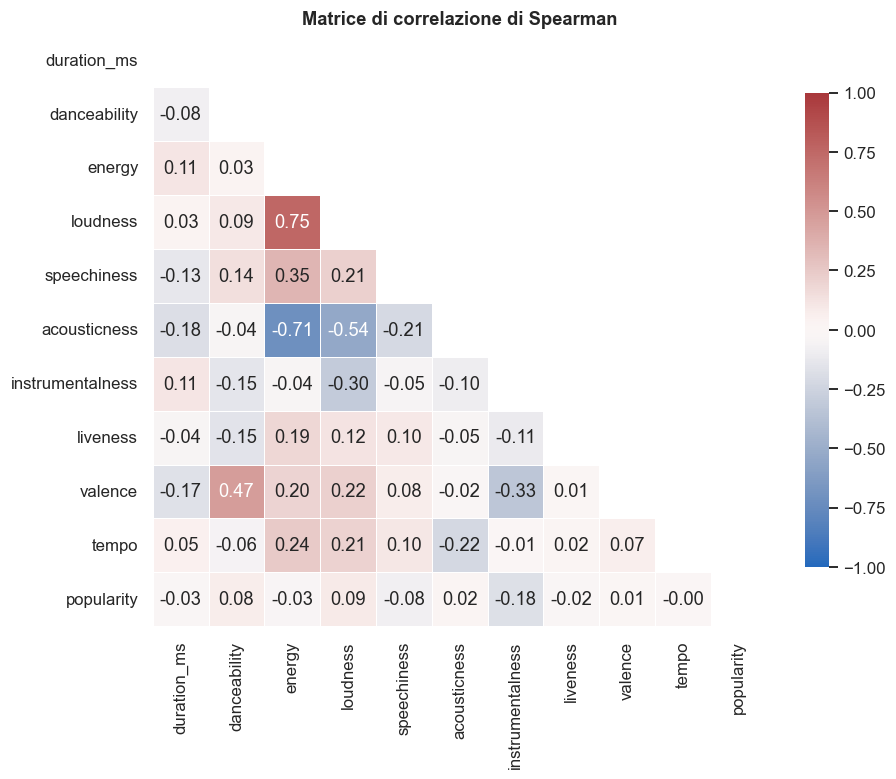

In [30]:
corr = df_clean[NUMERIC_FEATURES + [TARGET]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f",
    cmap="vlag", center=0, vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Matrice di correlazione di Spearman")
ax.grid(False)
show(fig, "06_correlazioni")

In [31]:
# Coppie di feature più correlate tra loro (escluso il target)
feature_corr = corr.loc[NUMERIC_FEATURES, NUMERIC_FEATURES]
feature_pairs = (
    feature_corr.where(np.tril(np.ones(feature_corr.shape), k=-1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
feature_pairs.head(8).round(3)

loudness          energy              0.754
acousticness      energy             -0.713
                  loudness           -0.536
valence           danceability        0.469
speechiness       energy              0.348
valence           instrumentalness   -0.329
instrumentalness  loudness           -0.298
tempo             energy              0.245
dtype: float64

Nessuna coppia supera 0.8 in valore assoluto: non c'è una ridondanza tale da imporre l'eliminazione di feature. Il gruppo `energy`, `loudness`, `acousticness` va comunque tenuto d'occhio.

Correlazione di ogni feature con `popularity`, su tutte le tracce e escludendo quelle con `popularity = 0`:

In [32]:
def corr_with_target(data):
    return data[NUMERIC_FEATURES + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET)


corr_comparison = pd.DataFrame({
    "tutte le tracce": corr_with_target(df_clean),
    "escluse popularity=0": corr_with_target(df_clean[df_clean[TARGET] > 0]),
}).sort_values("tutte le tracce", key=abs, ascending=False)
corr_comparison.round(3)

,tutte le tracce,escluse popularity=0
instrumentalness,-0.179,-0.196
loudness,0.087,0.078
speechiness,-0.083,-0.095
danceability,0.076,0.066
energy,-0.033,-0.068
duration_ms,-0.026,-0.037
liveness,-0.025,-0.039
acousticness,0.023,0.059
valence,0.010,-0.003
tempo,-0.003,-0.021


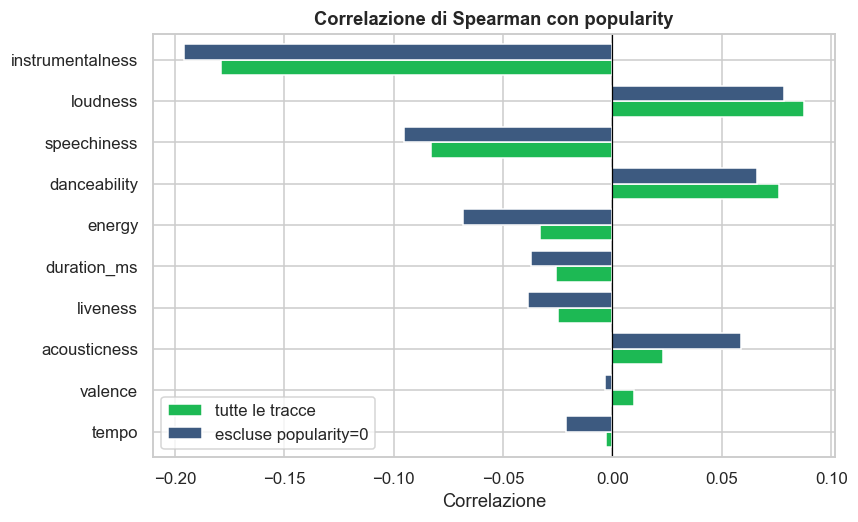

In [33]:
plot_data = corr_comparison.iloc[::-1]  # le correlazioni più forti (in valore assoluto) in alto

fig, ax = plt.subplots(figsize=(8, 5))
plot_data.plot.barh(ax=ax, color=[PRIMARY, NEUTRAL], width=0.75)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Correlazione di Spearman con popularity", xlabel="Correlazione", ylabel="")
ax.legend(title="")
show(fig, "07_correlazione_con_popularity")

Le correlazioni con `popularity` sono tutte deboli (al massimo circa 0.2 in valore assoluto, con `instrumentalness` in testa): nessuna feature audio spiega da sola la popolarità.

Escludendo le tracce a `popularity = 0` i valori cambiano di pochi centesimi e `instrumentalness` resta la più correlata; cambia solo leggermente l'ordine delle feature meno correlate. Le correlazioni restano tutte deboli: le tracce a 0 vengono quindi mantenute.

## 5. Classi di popolarità

Trasformiamo `popularity` in 4 classi usando i quartili. Le classi hanno numerosità simili ma non identiche (circa 24-26% ciascuna, perché `popularity` è un intero e molte tracce condividono lo stesso valore). Il riferimento per i modelli è il classificatore che predice sempre la classe più frequente: accuracy di circa 0.27.

Le soglie dei quartili sono calcolate sull'intero dataset prima dello split: dipendono solo dal target e la loro influenza sulla valutazione è trascurabile.

In [34]:
df_clean["pop_class"] = pd.qcut(df_clean[TARGET], q=4, labels=CLASS_LABELS)

print("Soglie dei quartili:", df_clean[TARGET].quantile([0.25, 0.5, 0.75]).tolist())
pd.DataFrame({
    "tracce": df_clean["pop_class"].value_counts().sort_index(),
    "quota": df_clean["pop_class"].value_counts(normalize=True).sort_index().round(3),
})

Soglie dei quartili: [21.0, 35.0, 50.0]


,tracce,quota
pop_class,,
bassa,22463,0.265
medio-bassa,20042,0.237
medio-alta,22152,0.262
alta,20052,0.237


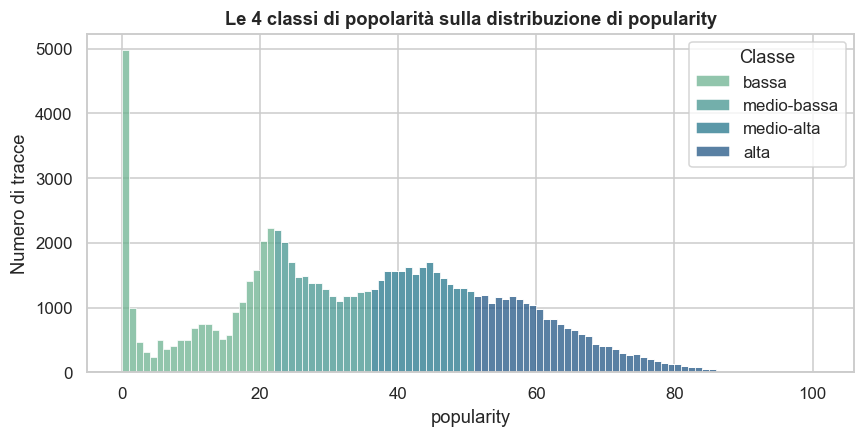

In [35]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(
    data=df_clean, x=TARGET, hue="pop_class", hue_order=CLASS_LABELS, palette=CLASS_COLORS,
    multiple="stack", bins=list(range(0, 102)), ax=ax,
)
ax.set(title="Le 4 classi di popolarità sulla distribuzione di popularity", xlabel="popularity", ylabel="Numero di tracce")
ax.get_legend().set_title("Classe")
show(fig, "08_classi_popolarita")

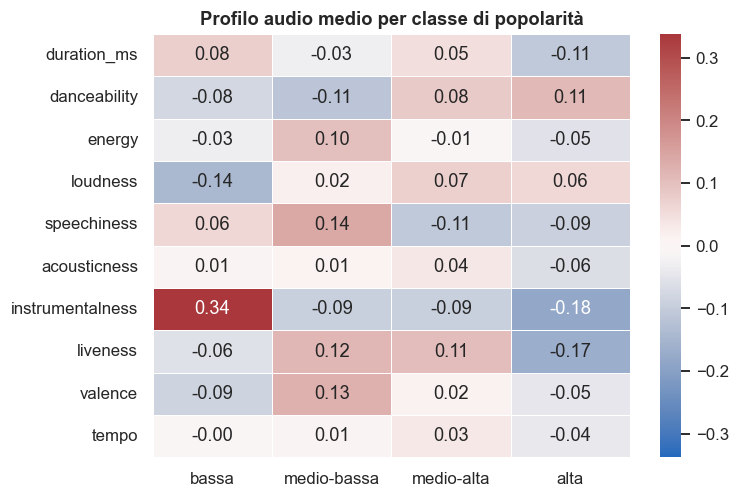

In [36]:
# Profilo audio medio di ogni classe, in deviazioni standard rispetto alla media generale
standardized = (df_clean[NUMERIC_FEATURES] - df_clean[NUMERIC_FEATURES].mean()) / df_clean[NUMERIC_FEATURES].std()
profile = standardized.groupby(df_clean["pop_class"], observed=True).mean().loc[CLASS_LABELS].T
limit = np.abs(profile.to_numpy()).max()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(profile, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-limit, vmax=limit, linewidths=0.5, ax=ax)
ax.set(title="Profilo audio medio per classe di popolarità", xlabel="", ylabel="")
ax.grid(False)
show(fig, "09_profilo_audio_per_classe")

**Commento:** Ogni cella è la media di una feature all'interno di una classe, espressa in deviazioni standard rispetto alla media generale del dataset. Un valore positivo (rosso) indica che, in media, i brani di quella classe hanno quella feature sopra la media; uno negativo (blu) sotto la media; valori vicini a 0 indicano nessuna differenza. Conta il confronto tra le colonne: una feature è associata alla popolarità se il suo valore cambia in modo ordinato passando da "bassa" ad "alta".

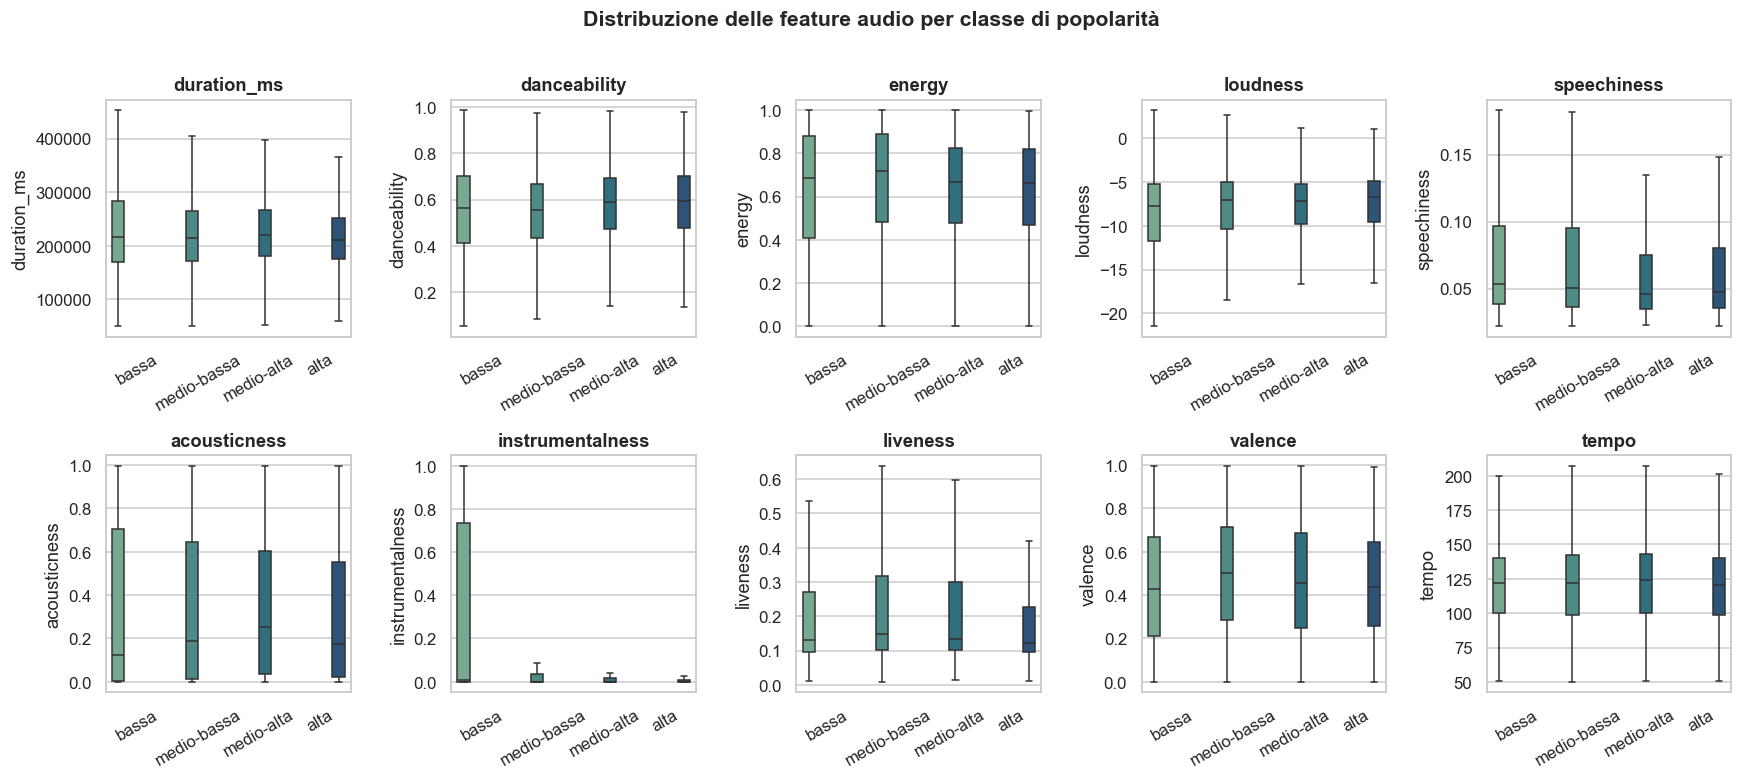

In [37]:
# Distribuzione completa delle feature nelle 4 classi
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, feature in zip(axes.flat, NUMERIC_FEATURES):
    sns.boxplot(
        data=df_clean, x="pop_class", y=feature, hue="pop_class", order=CLASS_LABELS, hue_order=CLASS_LABELS,
        palette=CLASS_COLORS, showfliers=False, legend=False, ax=ax,
    )
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Distribuzione delle feature audio per classe di popolarità", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
show(fig, "10_boxplot_feature_per_classe")

**Lettura.** Le differenze medie tra classi sono piccole (frazioni di deviazione standard) e i boxplot si sovrappongono molto: nessuna singola feature audio separa le classi. Il contributo congiunto delle feature è valutato nella sezione 7.6.

## 6. Analisi delle variabili categoriche

### 6.1 Preparazione: tonalità e time signature

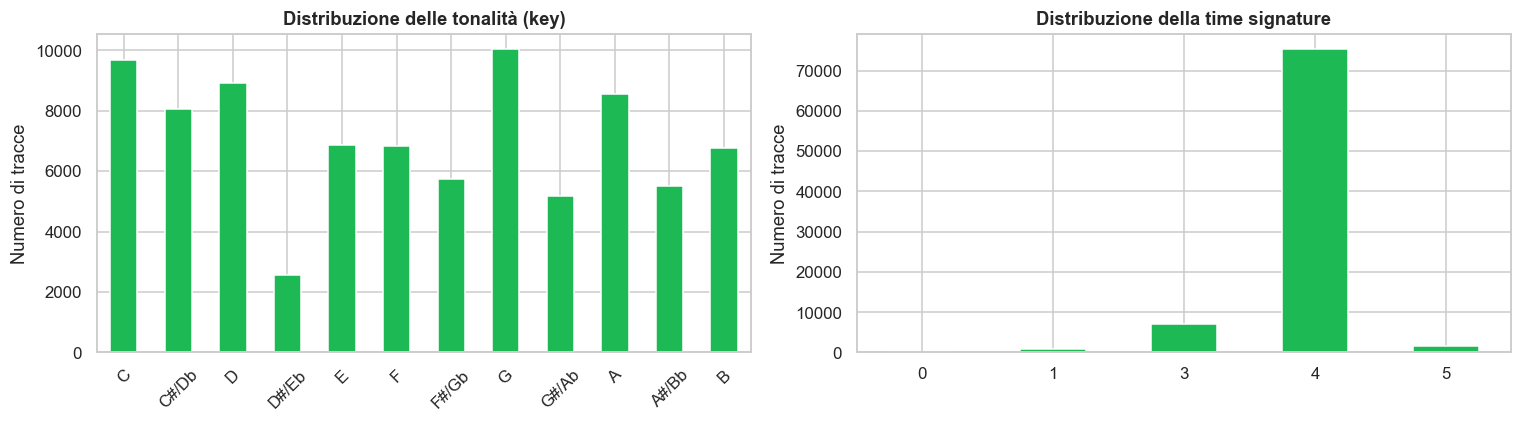

In [38]:
KEY_NAMES = ["C", "C#/Db", "D", "D#/Eb", "E", "F", "F#/Gb", "G", "G#/Ab", "A", "A#/Bb", "B"]

df_clean["key_name"] = df_clean["key"].map(dict(enumerate(KEY_NAMES)))
df_clean = df_clean.drop(columns="key")  # sostituita da key_name

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_clean["key_name"].value_counts().reindex(KEY_NAMES).plot.bar(ax=axes[0], color=PRIMARY, rot=45, title="Distribuzione delle tonalità (key)")
df_clean["time_signature"].value_counts().sort_index().plot.bar(ax=axes[1], color=PRIMARY, rot=0, title="Distribuzione della time signature")
for ax in axes:
    ax.set(xlabel="", ylabel="Numero di tracce")
plt.tight_layout()
show(fig, "11_key_time_signature")

In [39]:
# time_signature = 0 indica un valore non determinato da Spotify
df_clean["time_signature"] = df_clean["time_signature"].astype(str).replace({"0": "Sconosciuto"})

# Tutte le variabili categoriche come stringhe: unico tipo per test statistici e modelli
df_clean[CATEGORICAL_FEATURES] = df_clean[CATEGORICAL_FEATURES].astype(str)
df_clean["time_signature"].value_counts()

time_signature
4              75358
3               7082
5               1493
1                771
Sconosciuto        5
Name: count, dtype: int64

### 6.2 Associazione con le classi di popolarità

Per ogni variabile categorica si calcolano il test chi-quadro e il **V di Cramér**. Con decine di migliaia di righe i p-value sono sempre prossimi a zero: l'informazione utile è la *dimensione* dell'associazione (V di Cramér, da 0 a 1).

In [40]:
rows = []
for col in CATEGORICAL_FEATURES:
    table = pd.crosstab(df_clean[col], df_clean["pop_class"])
    chi2, p_value, _, _ = chi2_contingency(table)
    cramers_v = np.sqrt(chi2 / table.to_numpy().sum() / (min(table.shape) - 1))
    rows.append({"feature": col, "chi2": chi2, "p_value": p_value, "cramers_v": cramers_v})

categorical_association = pd.DataFrame(rows).sort_values("cramers_v", ascending=False)
categorical_association.round(3)

,feature,chi2,p_value,cramers_v
0,track_genre,81012.939,0.0,0.565
1,explicit,418.639,0.0,0.070
4,time_signature,478.281,0.0,0.043
3,mode,148.453,0.0,0.042
2,key_name,397.845,0.0,0.040


Il **genere musicale** è di gran lunga la variabile categorica più associata alla popolarità. Per vedere in che modo, confrontiamo la composizione in classi dei generi più e meno popolari in media (escludendo i generi con poche tracce).

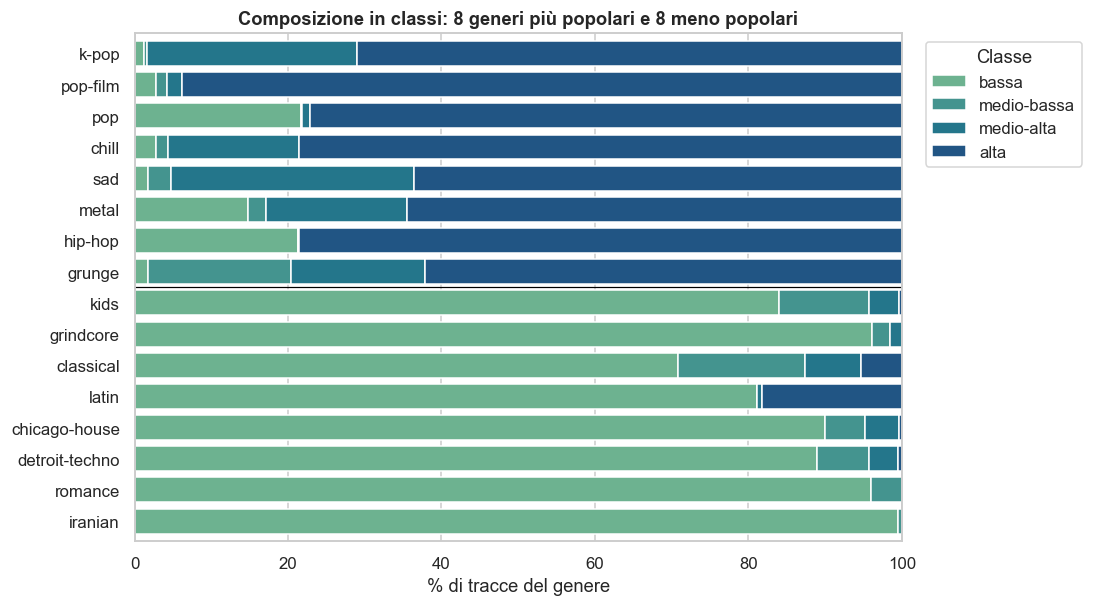

In [41]:
genre_stats = df_clean.groupby("track_genre")[TARGET].agg(["mean", "count"])
genre_stats = genre_stats[genre_stats["count"] >= MIN_GENRE_TRACKS].sort_values("mean", ascending=False)
n_show = min(8, len(genre_stats) // 2)
selected = list(genre_stats.index[:n_show]) + list(genre_stats.index[-n_show:])

shares = pd.crosstab(df_clean["track_genre"], df_clean["pop_class"], normalize="index").loc[selected, CLASS_LABELS] * 100

fig, ax = plt.subplots(figsize=(9, 6))
shares.plot.barh(stacked=True, width=0.8, color=[CLASS_COLORS[c] for c in CLASS_LABELS], ax=ax)
ax.invert_yaxis()  # i più popolari in alto
ax.axhline(n_show - 0.5, color="black", lw=0.8)
ax.legend(title="Classe", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set(title=f"Composizione in classi: {n_show} generi più popolari e {n_show} meno popolari", xlabel="% di tracce del genere", ylabel="")
show(fig, "12_generi_estremi")

In [42]:
# Omogeneità dei generi: quota della classe più frequente all'interno di ciascun genere
genre_class_share = pd.crosstab(df_clean["track_genre"], df_clean["pop_class"], normalize="index")
n_homogeneous = (genre_class_share.max(axis=1) >= 0.8).sum()
print(f"Generi in cui almeno l'80% delle tracce cade in una sola classe: {n_homogeneous} su {len(genre_class_share)}")

Generi in cui almeno l'80% delle tracce cade in una sola classe: 18 su 114


**Lettura.** Nei generi più popolari la maggior parte delle tracce cade nella classe "alta", in quelli meno popolari nella classe "bassa": il genere da solo sposta di molto la probabilità di appartenere a una classe.

## 7. Modelli di classificazione

### 7.1 Split train/test e pipeline

Il preprocessing (scaling e one-hot encoding) è incluso in una `Pipeline` insieme al modello: viene appreso solo sul train set, evitando data leakage dal test set.

**Split per brano**. Lo split usa GroupShuffleSplit, con circa l’80% dei dati nel train e il 20% nel test. Il gruppo è definito da track_name + artists normalizzati, così tutte le righe dello stesso brano rimangono nello stesso insieme. In questo modo, anche le copie dello stesso brano presenti con track_id diversi vengono mantenute nello stesso set. Gli assert verificano che nessun track_id e nessun brano siano presenti sia nel train sia nel test.


In [ ]:
# Gruppo = brano (titolo + artista normalizzati): le sue righe restano tutte nel train o tutte nel test
df_clean = df_clean.reset_index(drop=True)
df_clean["group_id"] = df_clean["track_name"].str.strip().str.casefold() + "||" + df_clean["artists"].str.strip().str.casefold()

# Ogni track_id deve appartenere a un solo gruppo, altrimenti lo split potrebbe dividere righe con lo stesso track_id
assert df_clean.groupby("track_id")["group_id"].nunique().max() == 1

# Feature e target
X = df_clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_clean["pop_class"].astype(str)

# Split per gruppo
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=df_clean["group_id"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train):,} righe | Test: {len(X_test):,} righe | Totale: {len(X_train) + len(X_test):,} righe")

# Verifiche: nessuna riga, track_id, brano (titolo + artista) in comune tra train e test
assert set(train_idx).isdisjoint(test_idx)
for column in ["track_id", "group_id"]:
    assert set(df_clean.iloc[train_idx][column]).isdisjoint(df_clean.iloc[test_idx][column]), column
assert not (set(map(tuple, df_clean.iloc[train_idx][SONG_KEY].to_numpy())) &
            set(map(tuple, df_clean.iloc[test_idx][SONG_KEY].to_numpy())))
print("Nessuna sovrapposizione tra train e test per riga, track_id e brano (titolo + artista).")

print(
    pd.DataFrame({
        "train": y_train.value_counts(normalize=True),
        "test": y_test.value_counts(normalize=True)
    }).round(3)
)

Train: 67,797 righe | Test: 16,912 righe | Totale: 84,709 righe
Nessuna sovrapposizione tra train e test per riga, track_id e brano (titolo + artista).
Righe di test con audio identico a una riga del train: 110 (0.7%)
Righe di test con artista principale presente nel train: 89.2%
             train   test
pop_class                
alta         0.237  0.237
bassa        0.265  0.266
medio-alta   0.263  0.256
medio-bassa  0.236  0.241


In [44]:
results, predictions = {}, {}
CLASS_RANK = {label: rank for rank, label in enumerate(CLASS_LABELS)}


def build_model(classifier, scale_numeric, numeric=NUMERIC_FEATURES, categorical=CATEGORICAL_FEATURES):
    """Preprocessing (scaling opzionale + one-hot) e classificatore in un'unica Pipeline."""
    preprocessor = ColumnTransformer([
        ("num", StandardScaler() if scale_numeric else "passthrough", numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([("preprocessing", preprocessor), ("classifier", classifier)])


def ordinal_mae(y_true, y_pred):
    """
    Errore medio assoluto tra classe reale e predetta sulla scala ordinata.
    Valori più bassi indicano errori mediamente meno gravi.
    """
    y_true_rank = y_true.map(CLASS_RANK).to_numpy()
    y_pred_rank = pd.Series(y_pred).map(CLASS_RANK).to_numpy()

    return np.mean(np.abs(y_true_rank - y_pred_rank))

def evaluate(model, name):
    """Calcola le metriche sul test set, le memorizza in `results` e stampa il report per classe."""
    
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 macro": f1_score(y_test, y_pred, average="macro"),
        "Errore ordinale medio": ordinal_mae(y_test, y_pred),
    }
    predictions[name] = y_pred
    print(f"{name} - accuracy: {results[name]['Accuracy']:.3f}\n")
    print(classification_report(y_test, y_pred, labels=CLASS_LABELS))
    return y_pred

### 7.2 Regressione Logistica

Modello lineare interpretabile: serve da riferimento. Richiede feature numeriche standardizzate.

In [45]:
lr_model = build_model(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), scale_numeric=True)
lr_model.fit(X_train, y_train)
y_pred_lr = evaluate(lr_model, "Regressione Logistica")

Regressione Logistica - accuracy: 0.611

              precision    recall  f1-score   support

       bassa       0.69      0.66      0.68      4502
 medio-bassa       0.57      0.62      0.59      4073
  medio-alta       0.63      0.56      0.59      4333
        alta       0.56      0.60      0.58      4004

    accuracy                           0.61     16912
   macro avg       0.61      0.61      0.61     16912
weighted avg       0.61      0.61      0.61     16912



Coefficienti delle feature numeriche (standardizzate) per ciascuna classe: un valore positivo aumenta la probabilità di appartenere a quella classe.

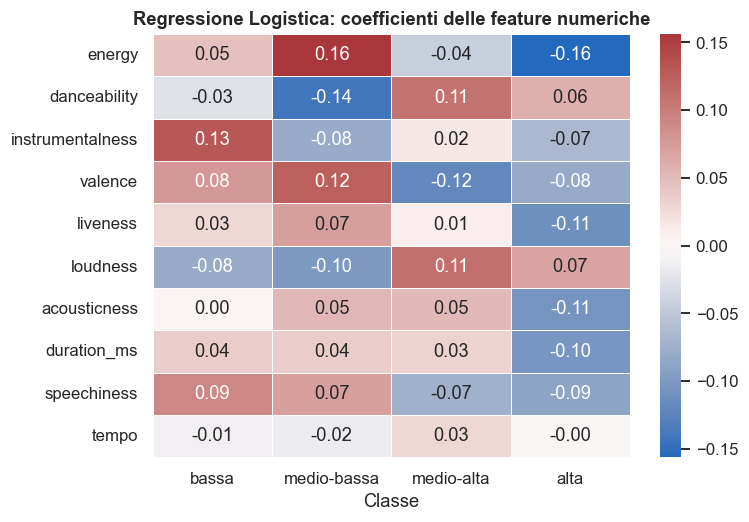

In [46]:
lr_classifier = lr_model.named_steps["classifier"]
feature_names = lr_model.named_steps["preprocessing"].get_feature_names_out()

lr_coefs = pd.DataFrame(lr_classifier.coef_, columns=feature_names, index=lr_classifier.classes_).loc[CLASS_LABELS]
lr_numeric_coefs = lr_coefs.filter(like="num__").T.rename(index=lambda name: name.removeprefix("num__"))
order = lr_numeric_coefs.abs().max(axis=1).sort_values(ascending=False).index
limit = lr_numeric_coefs.abs().to_numpy().max()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(lr_numeric_coefs.loc[order], annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-limit, vmax=limit, linewidths=0.5, ax=ax)
ax.set(title="Regressione Logistica: coefficienti delle feature numeriche", xlabel="Classe", ylabel="")
ax.grid(False)
show(fig, "14_coefficienti_logistica")

### 7.3 LightGBM

Modello a boosting di alberi: cattura relazioni non lineari e interazioni tra feature senza bisogno di scaling, costruendo gli alberi in sequenza per correggere gli errori dei precedenti. Gli iperparametri sono quelli di default (tranne `n_estimators = 500`): non c'è tuning né validation set, quindi il modello non è ottimizzato.

In [47]:
lgb_model = build_model(
    LGBMClassifier(**LGBM_PARAMS),
    scale_numeric=False,
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = evaluate(lgb_model, "LightGBM")

LightGBM - accuracy: 0.639

              precision    recall  f1-score   support

       bassa       0.70      0.66      0.68      4502
 medio-bassa       0.61      0.64      0.62      4073
  medio-alta       0.65      0.61      0.63      4333
        alta       0.60      0.64      0.62      4004

    accuracy                           0.64     16912
   macro avg       0.64      0.64      0.64     16912
weighted avg       0.64      0.64      0.64     16912



### 7.4 Confronto tra i modelli

Il riferimento è il classificatore che predice sempre la classe più frequente nel train.

,Accuracy,F1 macro,Errore ordinale medio
Regressione Logistica,0.611,0.610,0.588
LightGBM,0.639,0.638,0.545
Classe più frequente,0.266,0.105,1.464


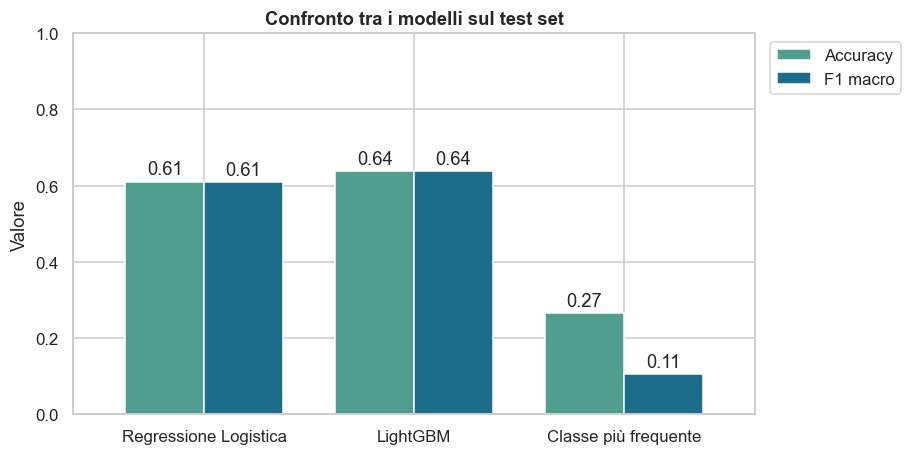

In [48]:
majority_class = y_train.value_counts().idxmax()
y_pred_baseline = np.full(len(y_test), majority_class)
results["Classe più frequente"] = {
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "F1 macro": f1_score(y_test, y_pred_baseline, average="macro", zero_division=0),
    "Errore ordinale medio": ordinal_mae(y_test, y_pred_baseline),
}
comparison = pd.DataFrame(results).T
display(comparison.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
comparison[["Accuracy", "F1 macro"]].plot.bar(ax=ax, rot=0, width=0.75, color=sns.color_palette("crest", 2))
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)
ax.set(title="Confronto tra i modelli sul test set", xlabel="", ylabel="Valore", ylim=(0, 1))
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
show(fig, "15_confronto_modelli")

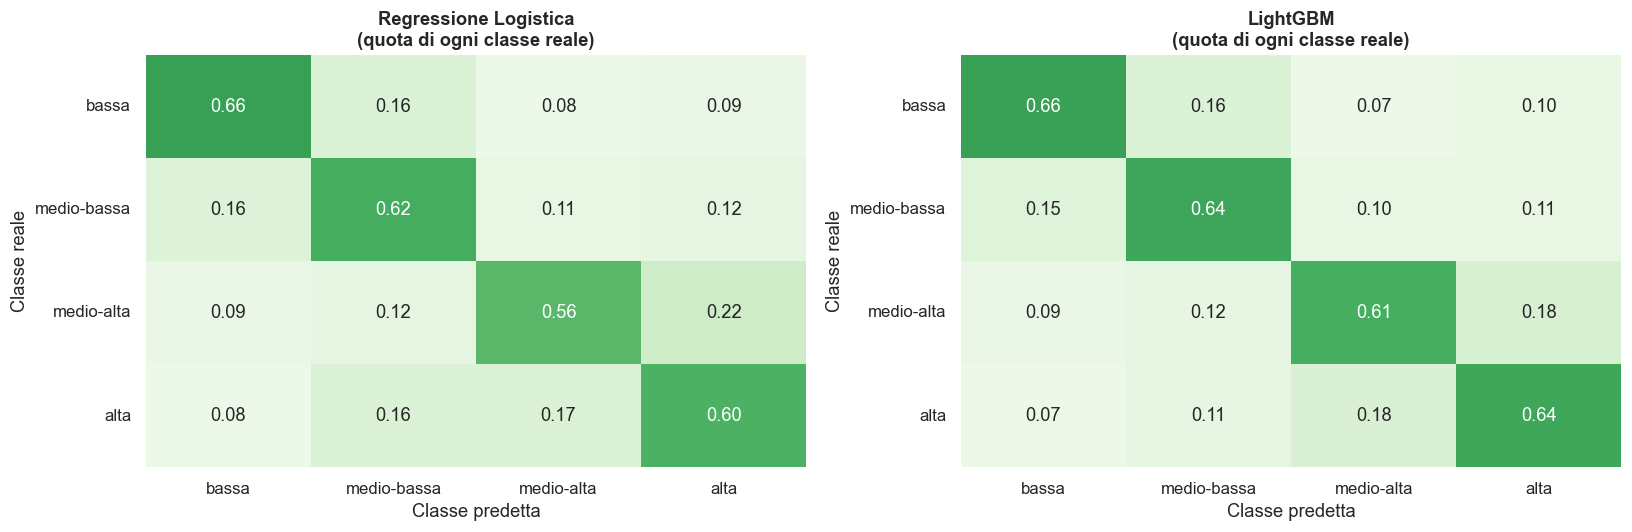

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, cbar=False,
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
    ax.set(title=f"{name}\n(quota di ogni classe reale)", xlabel="Classe predetta", ylabel="Classe reale")
    ax.grid(False)
    ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
show(fig, "16_matrici_confusione")

**Lettura.** Si leggano insieme la tabella e le matrici di confusione. L'errore ordinale medio dei due modelli è molto inferiore a quello del riferimento, e la maggior parte degli errori cade tra classi adiacenti. La classe "bassa" è la meglio riconosciuta; "alta" non è riconosciuta meglio delle classi intermedie.

### 7.5 Probabilità predette e calibrazione

Per ogni modello si valutano le probabilità di `predict_proba` con tre misure:
- **Brier Score** multiclasse (somma degli scarti quadratici sulle 4 classi, in media sulle tracce): 0 è il valore perfetto; il riferimento che assegna a ogni traccia le frequenze delle classi nel train vale circa 0.75.
- **Log-loss**: penalizza di più le probabilità basse assegnate alla classe corretta.
- **ECE top-label** (Expected Calibration Error, 10 intervalli di confidenza): differenza media tra la confidenza della classe predetta e la sua accuracy reale. Misura la calibrazione, non la capacità di distinguere le classi.

Le probabilità non sono ricalibrate: si valuta quelle prodotte direttamente dai modelli.

In [ ]:
def get_ordered_probabilities(model, X):
    """Probabilità predette, con le colonne nello stesso ordine di CLASS_LABELS."""
    proba = pd.DataFrame(model.predict_proba(X), columns=model.classes_)
    return proba[CLASS_LABELS].to_numpy()


proba_lr = get_ordered_probabilities(lr_model, X_test)
proba_lgb = get_ordered_probabilities(lgb_model, X_test)

# Target in forma numerica (rango della classe) e one-hot, nello stesso ordine di CLASS_LABELS
y_test_rank = y_test.map(CLASS_RANK).to_numpy()
y_test_onehot = np.eye(len(CLASS_LABELS))[y_test_rank]


Regressione Logistica: somma per riga tra 1.000000 e 1.000000 | valori fuori [0,1]: 0 | NaN: 0
LightGBM: somma per riga tra 1.000000 e 1.000000 | valori fuori [0,1]: 0 | NaN: 0
Classi del modello (ordine di predict_proba): ['alta', 'bassa', 'medio-alta', 'medio-bassa'] | ordine usato: ['bassa', 'medio-bassa', 'medio-alta', 'alta']


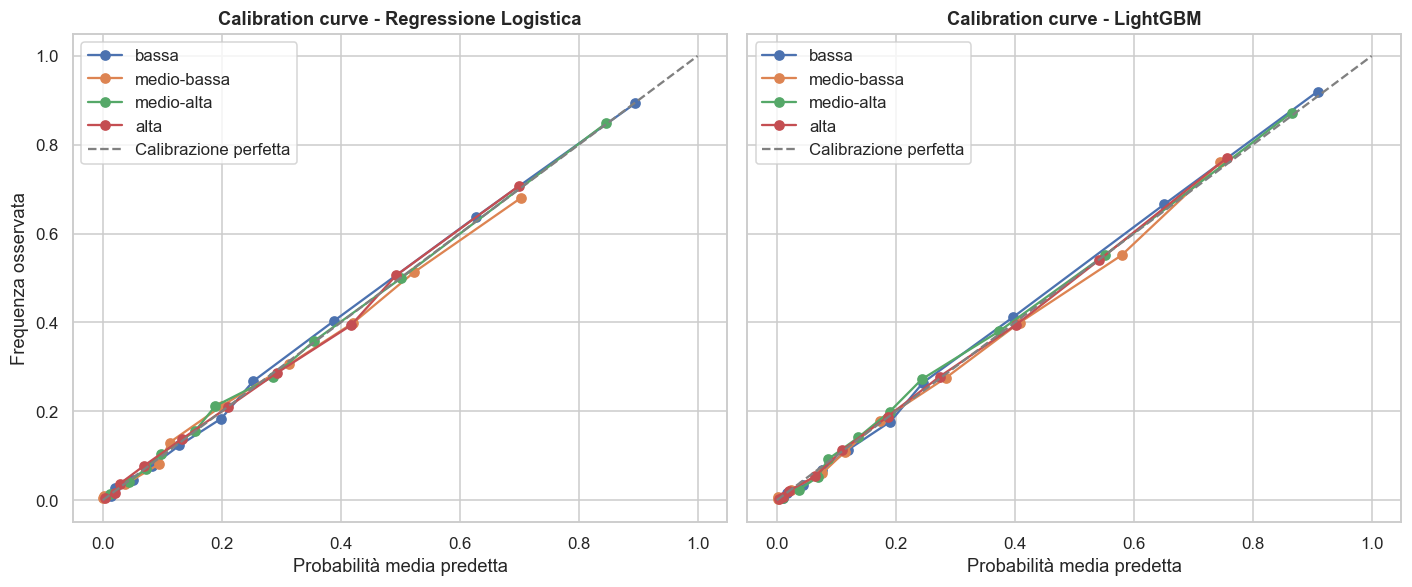

In [ ]:
# Calibration curve di LightGBM (10 intervalli con lo stesso numero di tracce) per ciascuna classe
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for k, class_name in enumerate(CLASS_LABELS):
    prob_mean, observed_frequency = calibration_curve(y_test_onehot[:, k], proba_lgb[:, k], n_bins=10, strategy="quantile")
    ax.plot(prob_mean, observed_frequency, marker="o", label=class_name)
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="Calibrazione perfetta")
ax.set(title="Calibration curve - LightGBM", xlabel="Probabilità media predetta", ylabel="Frequenza osservata")
ax.legend()
plt.tight_layout()
show(fig, "17_calibration_curve")

In [ ]:
def top_label_ece(proba, y_rank):
    """ECE sulla classe predetta (10 intervalli di confidenza) e tabella per intervallo."""
    confidence = proba.max(axis=1)
    correct = (proba.argmax(axis=1) == y_rank).astype(int)
    bins = np.minimum((confidence * 10).astype(int), 9)
    table = (
        pd.DataFrame({"bin": bins, "confidence": confidence, "correct": correct})
        .groupby("bin")
        .agg(confidence=("confidence", "mean"), accuracy=("correct", "mean"), n=("correct", "size"))
    )
    ece = np.average((table["accuracy"] - table["confidence"]).abs(), weights=table["n"])
    return ece, table


def multiclass_brier(y_onehot, probabilities):
    return np.mean(np.sum((probabilities - y_onehot) ** 2, axis=1))


# Riferimento: a ogni traccia si assegnano le frequenze delle classi nel train
prior = y_train.map(CLASS_RANK).value_counts(normalize=True).sort_index().to_numpy()
proba_prior = np.tile(prior, (len(y_test_onehot), 1))

ece_lr, _ = top_label_ece(proba_lr, y_test_rank)
ece_lgb, bins_lgb = top_label_ece(proba_lgb, y_test_rank)

probability_metrics = pd.DataFrame({
    "Regressione Logistica": {
        "Brier Score": multiclass_brier(y_test_onehot, proba_lr),
        "Log-loss": log_loss(y_test_rank, proba_lr, labels=np.arange(len(CLASS_LABELS))),
        "ECE top-label": ece_lr,
    },
    "LightGBM": {
        "Brier Score": multiclass_brier(y_test_onehot, proba_lgb),
        "Log-loss": log_loss(y_test_rank, proba_lgb, labels=np.arange(len(CLASS_LABELS))),
        "ECE top-label": ece_lgb,
    },
    "Riferimento (frequenze delle classi)": {
        "Brier Score": multiclass_brier(y_test_onehot, proba_prior),
        "Log-loss": log_loss(y_test_rank, proba_prior, labels=np.arange(len(CLASS_LABELS))),
        "ECE top-label": np.nan,
    },
}).T
# Brier skill score: 1 = perfetto, 0 = come il riferimento
probability_metrics["Brier skill score"] = 1 - probability_metrics["Brier Score"] / probability_metrics.loc["Riferimento (frequenze delle classi)", "Brier Score"]
display(probability_metrics.round(4))

print("LightGBM: confidenza della classe predetta e accuracy osservata, per intervallo")
display(bins_lgb.round(3))

### 7.6 Quanto contano genere e feature audio

Per separare il contributo delle due famiglie di variabili si riaddestrano gli stessi modelli con sottoinsiemi di feature (stesso split, stesse impostazioni) e si confronta l'accuracy sul test set.

In [53]:
feature_sets = {
    "Solo feature audio": (NUMERIC_FEATURES, []),
    "Solo genere": ([], ["track_genre"]),
    "Audio + genere": (NUMERIC_FEATURES, ["track_genre"]),
    "Tutte le feature": (NUMERIC_FEATURES, CATEGORICAL_FEATURES),
}
ablation = {}
for label, (numeric, categorical) in feature_sets.items():
    lr_subset = build_model(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True, numeric, categorical)
    lgb_subset = build_model(LGBMClassifier(**LGBM_PARAMS), False, numeric, categorical)
    ablation[label] = {
        name: accuracy_score(y_test, model.fit(X_train, y_train).predict(X_test))
        for name, model in [("Regressione Logistica", lr_subset), ("LightGBM", lgb_subset)]
    }
display(pd.DataFrame(ablation).T.round(3))
print(f"Riferimento (classe più frequente): {results['Classe più frequente']['Accuracy']:.3f}")

,Regressione Logistica,LightGBM
Solo feature audio,0.349,0.423
Solo genere,0.603,0.603
Audio + genere,0.611,0.639
Tutte le feature,0.611,0.639


Riferimento (classe più frequente): 0.266


### 7.7 Cosa guida le predizioni di LightGBM?

L'importanza calcolata sulle colonne dopo il one-hot encoding frammenta il genere su decine di colonne e favorisce le variabili continue. Per questo si confrontano due misure riferite alle **colonne originali**:

- importanza per guadagno (`gain`), sommando le colonne one-hot di ciascuna variabile: contributo totale degli split di quella variabile alla riduzione della loss;
- importanza per permutazione: calo di accuracy sul test set quando i valori di una colonna vengono rimescolati (calcolata su un campione di 5.000 tracce per contenere i tempi).

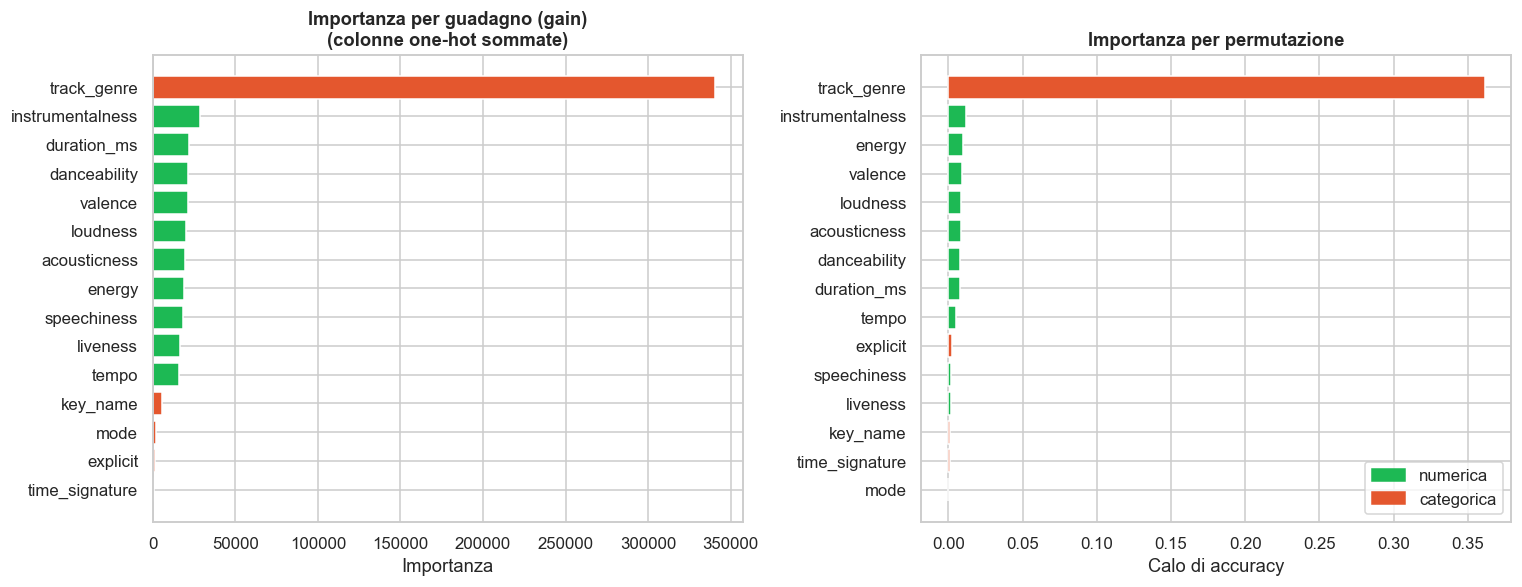

In [54]:
lgb_classifier = lgb_model.named_steps["classifier"]
lgb_feature_names = lgb_model.named_steps["preprocessing"].get_feature_names_out()


def original_feature(encoded_name):
    """Riporta un nome come 'cat__track_genre_rock' alla colonna di origine 'track_genre'."""
    name = encoded_name.split("__", 1)[1]
    return next((col for col in CATEGORICAL_FEATURES if name.startswith(col + "_")), name)


gain = (
    pd.Series(lgb_classifier.feature_importances_, index=lgb_feature_names)
    .groupby(original_feature).sum().sort_values()
)

sample = X_test.sample(min(5_000, len(X_test)), random_state=RANDOM_STATE)
perm = permutation_importance(
    lgb_model, sample, y_test.loc[sample.index], scoring="accuracy",
    n_repeats=3, random_state=RANDOM_STATE, n_jobs=1,
)
permutation = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
panels = [
    (axes[0], gain, "Importanza per guadagno (gain)\n(colonne one-hot sommate)", "Importanza"),
    (axes[1], permutation, "Importanza per permutazione", "Calo di accuracy"),
]
for ax, series, title, xlabel in panels:
    ax.barh(series.index, series.values, color=[PRIMARY if f in NUMERIC_FEATURES else ALERT for f in series.index])
    ax.set(title=title, xlabel=xlabel)
axes[1].legend(handles=[Patch(color=PRIMARY, label="numerica"), Patch(color=ALERT, label="categorica")], loc="lower right")
plt.tight_layout()
show(fig, "18_importanza_feature")

Il genere (`track_genre`) risulta la variabile più importante con entrambe le misure, con un distacco netto dalle altre. Le feature audio hanno importanza per permutazione piccola e simile tra loro. Entrambe le misure descrivono il modello, non un effetto causale del genere sulla popolarità; alcune feature audio sono molto correlate tra loro (per esempio `energy` e `loudness`, sezione 4.3), quindi l'importanza di ciascuna va letta con cautela.

### 7.8 SHAP: uno sguardo più fine a LightGBM

L'importanza per permutazione dice *quanto* pesa ogni variabile, ma non *come*: non dice se un genere spinga verso una popolarità alta o bassa, né come cambi il contributo di una feature audio al variare del suo valore. I valori **SHAP** (SHapley Additive exPlanations) scompongono ogni predizione nel contributo delle singole feature e permettono di leggere sia l'effetto medio sul dataset sia la spiegazione di una singola traccia.

In [55]:
SHAP_SAMPLE_SIZE = 5000  # campione piccolo: basta per leggere le tendenze, resta veloce
CLASS_TO_EXPLAIN = "alta"

shap_sample = X_test.sample(min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
shap_sample_transformed = lgb_model.named_steps["preprocessing"].transform(shap_sample)
if hasattr(shap_sample_transformed, "toarray"):
    shap_sample_transformed = shap_sample_transformed.toarray()

print(shap_sample_transformed.shape)

(5000, 145)


In [56]:
lgb_classifier = lgb_model.named_steps["classifier"]
class_index = list(lgb_classifier.classes_).index(CLASS_TO_EXPLAIN)

explainer = shap.TreeExplainer(lgb_classifier)
raw_shap_values = explainer.shap_values(shap_sample_transformed, check_additivity=False)

# Normalizza l'output tra le diverse versioni di SHAP:
# lista di un array per classe oppure un unico array con la classe come ultima dimensione
shap_values = raw_shap_values[class_index] if isinstance(raw_shap_values, list) else raw_shap_values[:, :, class_index]

print(f"Valori SHAP calcolati su {shap_values.shape[0]} tracce, classe '{CLASS_TO_EXPLAIN}'.")

Valori SHAP calcolati su 5000 tracce, classe 'alta'.


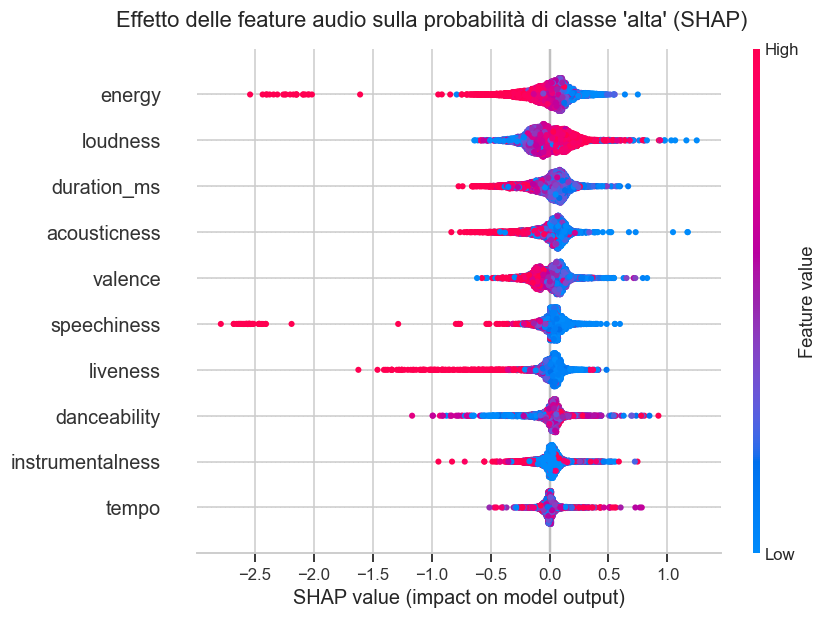

In [57]:
numeric_idx = [i for i, name in enumerate(lgb_feature_names) if original_feature(name) in NUMERIC_FEATURES]
numeric_names = [original_feature(lgb_feature_names[i]) for i in numeric_idx]

shap.summary_plot(
    shap_values[:, numeric_idx],
    shap_sample_transformed[:, numeric_idx],
    feature_names=numeric_names,
    show=False,
)

fig = plt.gcf()
fig.suptitle(f"Effetto delle feature audio sulla probabilità di classe '{CLASS_TO_EXPLAIN}' (SHAP)", y=1.02)

show(fig, "19_shap_summary_numeriche")

**Lettura.** Ogni punto è una traccia del campione: la posizione orizzontale è il contributo della feature alla classe "alta", il colore il valore della feature. Per le feature audio i contributi sono in gran parte vicini a zero e le relazioni con il valore della feature sono deboli e non sempre monotone. Il segno è coerente con i coefficienti della Regressione Logistica (per esempio `energy` alta spinge lontano dalla classe "alta"), ma gli effetti sono piccoli.

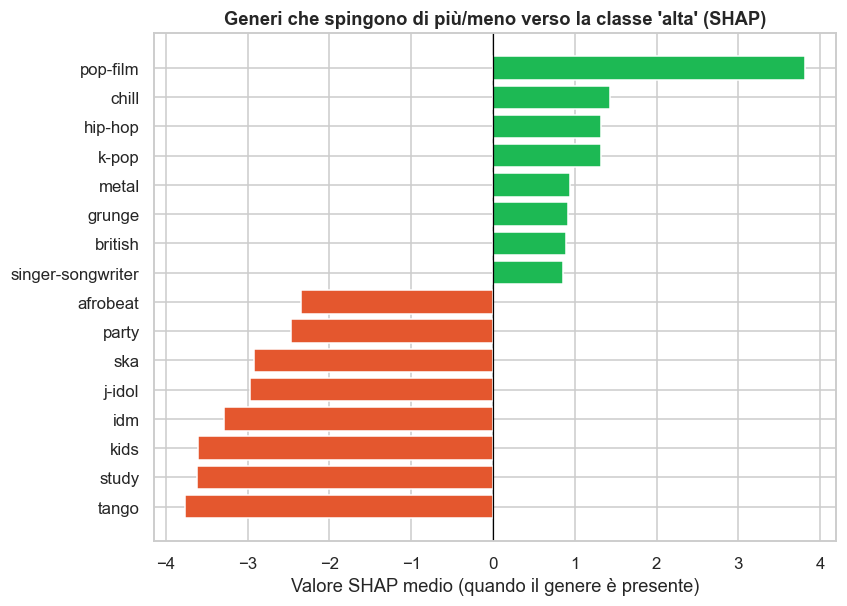

In [58]:
genre_idx = [i for i, name in enumerate(lgb_feature_names) if original_feature(name) == "track_genre"]

genre_effects = []
for i in genre_idx:
    genre_name = lgb_feature_names[i].split("__", 1)[1].removeprefix("track_genre_")
    active = shap_sample_transformed[:, i] == 1
    if active.sum() >= 5:  # generi troppo rari nel campione non sono affidabili
        genre_effects.append({"genre": genre_name, "shap_mean": shap_values[active, i].mean(), "n": int(active.sum())})

genre_effects = pd.DataFrame(genre_effects).sort_values("shap_mean")
top_bottom = pd.concat([genre_effects.head(8), genre_effects.tail(8)])

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(top_bottom["genre"], top_bottom["shap_mean"], color=[ALERT if v < 0 else PRIMARY for v in top_bottom["shap_mean"]])
ax.axvline(0, color="black", lw=0.8)
ax.set(title=f"Generi che spingono di più/meno verso la classe '{CLASS_TO_EXPLAIN}' (SHAP)",
       xlabel="Valore SHAP medio (quando il genere è presente)", ylabel="")

show(fig, "20_shap_generi")

**Lettura.** Il grafico mostra, per ciascun genere, il contributo SHAP medio alla classe "alta" nei brani del campione di quel genere. Sono riportati gli 8 generi con il contributo più positivo e gli 8 con quello più negativo, tra quelli presenti almeno 5 volte nel campione. Il modello associa quindi alcuni generi a previsioni più favorevoli alla classe "alta" e altri a previsioni meno favorevoli, con contributi molto più ampi di quelli delle singole feature audio.

**Cautele.** I valori SHAP sono espressi in scala logit, non in percentuali, e descrivono il comportamento del modello, non un rapporto causale tra genere e popolarità.

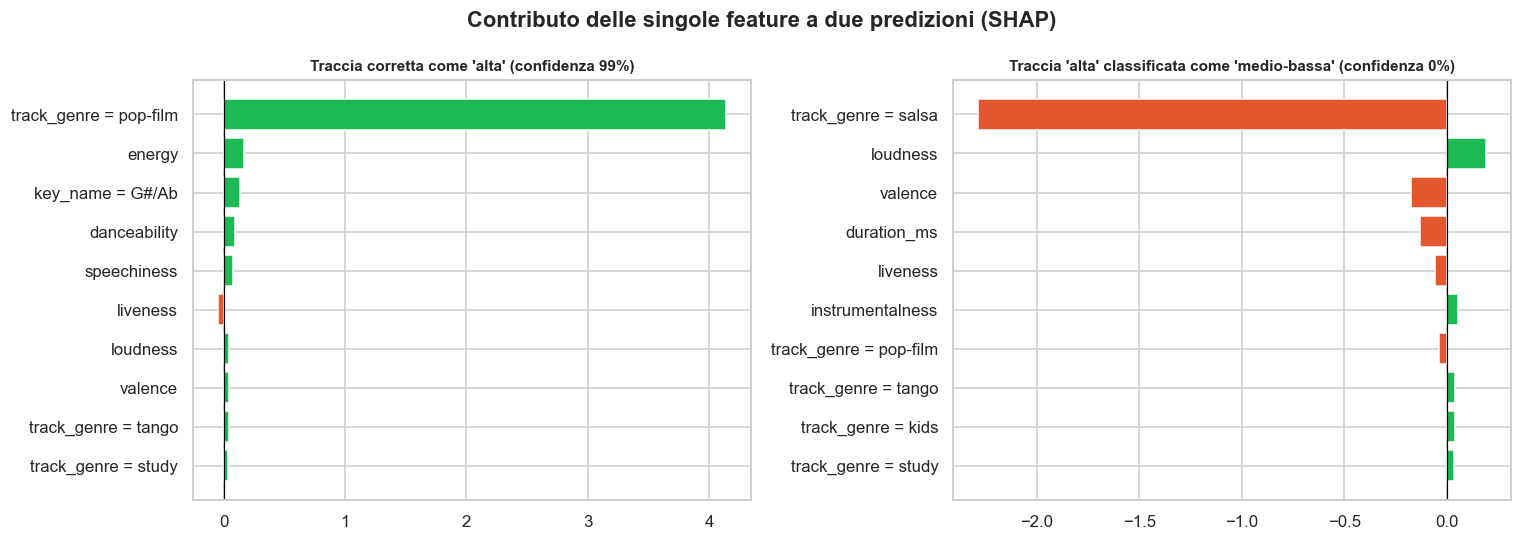

In [59]:
lgb_classifier = lgb_model.named_steps["classifier"]

proba = lgb_classifier.predict_proba(shap_sample_transformed)
predicted = lgb_classifier.classes_[proba.argmax(axis=1)]
actual = y_test.loc[shap_sample.index].to_numpy()


def display_name(encoded_name):
    base = original_feature(encoded_name)
    raw = encoded_name.split("__", 1)[1]
    return f"{base} = {raw[len(base) + 1:]}" if base in CATEGORICAL_FEATURES else raw


display_names = [display_name(name) for name in lgb_feature_names]


def plot_local_explanation(row, title, ax):
    """Bar chart delle feature che più contribuiscono alla predizione di una singola traccia."""
    contributions = pd.Series(shap_values[row], index=display_names).sort_values(key=abs).tail(10)
    ax.barh(contributions.index, contributions.values, color=[ALERT if v < 0 else PRIMARY for v in contributions])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(title, fontsize=10)


correct_high_conf = np.where((predicted == CLASS_TO_EXPLAIN) & (actual == CLASS_TO_EXPLAIN))[0]
wrong_should_be = np.where((actual == CLASS_TO_EXPLAIN) & (predicted != CLASS_TO_EXPLAIN))[0]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(correct_high_conf):
    row = correct_high_conf[proba[correct_high_conf, class_index].argmax()]
    plot_local_explanation(
        row,
        f"Traccia corretta come '{CLASS_TO_EXPLAIN}' (confidenza {proba[row, class_index]:.0%})",
        axes[0]
    )

if len(wrong_should_be):
    row = wrong_should_be[proba[wrong_should_be, class_index].argmin()]
    plot_local_explanation(
        row,
        f"Traccia '{CLASS_TO_EXPLAIN}' classificata come '{predicted[row]}' (confidenza {proba[row, class_index]:.0%})",
        axes[1]
    )

fig.suptitle("Contributo delle singole feature a due predizioni (SHAP)", fontweight="bold")

plt.tight_layout()

show(fig, "21_shap_esempi_locali")

**Lettura.** Gli esempi locali mostrano due singole tracce (la più sicura tra quelle correttamente predette come "alta" e un caso di classe "alta" classificato altrove): in entrambi i casi il contributo più grande è quello del genere, mentre le singole feature audio contano molto meno. Sono illustrazioni di due casi, non risultati generali.

### Controllo di coerenza con le conclusioni

La cella seguente verifica che i valori citati nelle conclusioni (arrotondati) coincidano con quelli appena calcolati: se si modificano dati, split o parametri e un controllo fallisce, vanno aggiornate le conclusioni.

In [61]:
assert abs(results["Regressione Logistica"]["Accuracy"] - 0.61) < 0.01
assert abs(results["LightGBM"]["Accuracy"] - 0.64) < 0.015
assert results["LightGBM"]["Accuracy"] > results["Regressione Logistica"]["Accuracy"] > results["Classe più frequente"]["Accuracy"] + 0.3
assert abs(probability_metrics.loc["Regressione Logistica", "Brier Score"] - 0.50) < 0.01
assert abs(probability_metrics.loc["LightGBM", "Brier Score"] - 0.48) < 0.02
assert (probability_metrics.loc[["Regressione Logistica", "LightGBM"], "ECE top-label"] < 0.03).all()
assert abs(ablation["Solo genere"]["Regressione Logistica"] - 0.60) < 0.01
assert abs(ablation["Solo feature audio"]["Regressione Logistica"] - 0.35) < 0.01
assert ablation["Audio + genere"]["LightGBM"] > ablation["Solo genere"]["LightGBM"]
assert permutation["track_genre"] > 5 * permutation.drop("track_genre").max()
print("Valori citati nelle conclusioni confermati.")

Valori citati nelle conclusioni confermati.


## 8. Conclusioni

**Risultati** (test set: circa 16.900 tracce di brani non visti in addestramento)

- **Dati.** Dopo la pulizia restano 84.709 righe su 114.000. Quasi tutta la riduzione (27.264 righe) è dovuta ai duplicati esatti: la stessa registrazione compare in più generi (nella grande maggioranza dei gruppi di duplicati le copie hanno generi diversi, vedi sezione 2). Il resto sono 949 quasi-duplicati e tracce a 0 con copia positiva, 858 tracce per durata fuori dai percentili 0.5-99.5 e 219 con tempo sotto 50 BPM.
- **Variabili.** Le correlazioni di Spearman tra feature audio e `popularity` sono deboli (al massimo circa 0.18 in valore assoluto, `instrumentalness`). Il genere è la variabile categorica più associata alle classi di popolarità (V di Cramér circa 0.57; le altre non superano 0.07).
- **Classificazione in 4 classi.** La Regressione Logistica ottiene accuracy 0.61 e LightGBM circa 0.64, contro 0.27 del classificatore che predice sempre la classe più frequente. L'errore ordinale medio della Regressione Logistica è 0.59 (riferimento: 1.46) e la maggior parte degli errori cade tra classi adiacenti.
- **Genere e audio.** Con la Regressione Logistica le sole feature audio raggiungono accuracy 0.35, il solo genere 0.60 e tutte le feature 0.61. Con LightGBM la tabella 7.6 mostra un guadagno maggiore dall'aggiunta delle feature audio al genere. Permutation importance e SHAP indicano il genere come variabile dominante, con un distacco netto dalle feature audio.
- **Probabilità e calibrazione.** Entrambi i modelli migliorano nettamente il riferimento basato sulle frequenze delle classi: per la Regressione Logistica Brier Score 0.50 contro 0.75 (Brier skill score circa 0.33) e log-loss 0.91 contro 1.39; per LightGBM Brier Score circa 0.48 (tabella in 7.5). L'ECE è basso per entrambi (circa 0.01-0.02) e la calibration curve di LightGBM segue la diagonale: sul test set le probabilità sono ben calibrate, senza alcuna ricalibrazione. Questo non significa che le singole previsioni siano affidabili ovunque: circa il 10% delle tracce riceve una confidenza superiore a 0.9 (accuracy circa 0.95 per la Regressione Logistica, tabella in 7.5), e sono soprattutto tracce di generi in cui quasi tutti i brani cadono in una sola classe (in 18 generi su 114 almeno l'80% delle tracce è in una classe).

**Interpretazione** (coerente con i risultati, ma non dimostrata da essi)

- Le feature audio da sole hanno un potere predittivo limitato ma superiore al caso (0.35 contro 0.27 con la Regressione Logistica). Quasi tutta la capacità predittiva proviene dal genere.
- Che il genere sia un indicatore della dimensione del pubblico o delle dinamiche di mercato è un'ipotesi: il notebook non la verifica. SHAP e importanza delle feature descrivono il comportamento dei modelli, non cause della popolarità.

**Limiti**

- **Campione.** Il dataset ha circa 1.000 tracce per genere ed è costruito per genere: non è un campione casuale delle tracce di Spotify. I risultati valgono per questo campione e il peso del genere dipende anche da quanto sono omogenei i generi al suo interno.
- **Genere dei duplicati.** Per le registrazioni presenti in più generi, il genere conservato è scelto a caso: il genere di una traccia è quindi in parte arbitrario, e questo aggiunge rumore alla variabile più importante.
- **Target.** `popularity` è un indice istantaneo di Spotify, non una proprietà del brano. Parte degli zeri è probabilmente assenza di dato, e la fase A della deduplica seleziona le righe in base al target (scelta dichiarata). Le 4 classi derivano dai quartili: perdono informazione e gli errori vicini alle soglie pesano come quelli lontani.
-**Valutazione**. La valutazione si basa su una singola partizione train/test, senza intervalli di incertezza né ottimizzazione degli iperparametri: differenze di pochi centesimi vanno quindi interpretate con cautela. Lo split per brano evita la presenza dello stesso brano nel train e nel test.
- **Calibrazione.** La calibrazione è valutata sullo stesso test set usato per le altre metriche, con un ECE a 10 intervalli: indica coerenza media tra confidenza e accuracy, non affidabilità per singola traccia.